# Statistics for Machine Learning — Notebook 1  
# Descriptive Statistics and Data Understanding

## Why this notebook matters

Machine Learning is not only models.

Before training any model, a serious AI engineer must understand the data.

Statistics helps us answer:

- What is the center of the data?
- How spread out is the data?
- Are there outliers?
- Are features related?
- Is the data skewed?
- Are features on different scales?
- Can this feature help a model?
- Is there a data quality problem?

In this notebook, we will learn statistics from an ML point of view.

---

## What you will learn

1. Population vs sample  
2. Mean, median, mode  
3. Range, variance, standard deviation  
4. Quartiles and interquartile range  
5. Percentiles  
6. Z-score  
7. Outlier detection  
8. Skewness and kurtosis  
9. Covariance and correlation  
10. Why scaling matters in ML  
11. Statistical summary for ML datasets  
12. Mini project: statistical EDA report

# 1. Statistics in Machine Learning

Statistics is the language of data.

In machine learning, we use statistics to:

| ML Stage | Statistical idea |
|---|---|
| Data cleaning | missing values, outliers |
| Feature engineering | scaling, transformations |
| EDA | distributions, spread, correlation |
| Model training | loss, variance, bias |
| Evaluation | confidence, error, metrics |
| Decision-making | probability, uncertainty |

A model learns patterns from data.  
If we do not understand the data, we cannot understand the model.

# 2. Setup

Run this cell first.

If something is missing:

```python
!pip install numpy pandas matplotlib seaborn scipy scikit-learn ipywidgets
```

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

try:
    import ipywidgets as widgets
    from ipywidgets import interact
    WIDGETS_AVAILABLE = True
except Exception:
    WIDGETS_AVAILABLE = False
    print("ipywidgets is not available. Install it using: pip install ipywidgets")

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

np.random.seed(42)

%matplotlib inline
sns.set_theme(style="whitegrid")

print("Setup complete.")

Setup complete.


# 3. Population vs Sample

## Population

Population means the complete group we want to study.

Example:

- all customers of a company
- all students in a university
- all images in the world
- all possible transactions

## Sample

Sample means a smaller part of the population.

Example:

- 1000 customers from all customers
- 500 images from a huge image dataset
- 2000 transactions from one month

In ML, we usually work with samples because the full population is not available.

Important idea:

> A model trained on a sample should generalize to unseen data from the population.

Population mean: 70.01
Sample mean: 69.83


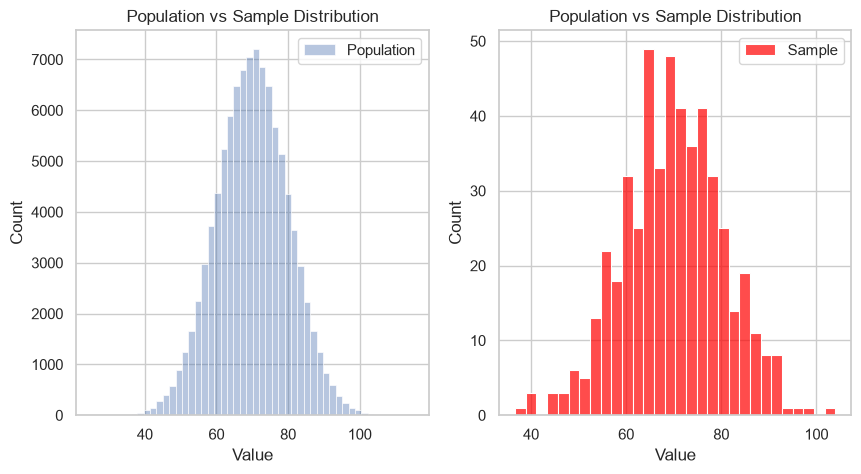

In [2]:
# Example population and sample

population = np.random.normal(loc=70, scale=10, size=100000)
sample = np.random.choice(population, size=500, replace=False)

print("Population mean:", population.mean().round(2))
print("Sample mean:", sample.mean().round(2))

plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
sns.histplot(population, bins=50, label="Population", alpha=0.4)
plt.title("Population vs Sample Distribution")
plt.xlabel("Value")
plt.ylabel("Count")
plt.legend()
plt.subplot(1,2,2)
sns.histplot(sample, bins=30, label="Sample", alpha=0.7, color='red')
plt.title("Population vs Sample Distribution")
plt.xlabel("Value")
plt.ylabel("Count")
plt.legend()
plt.show()

# 4. Create an ML-style dataset

We will create a synthetic customer dataset.

Target:

- `churn = 1`: customer left
- `churn = 0`: customer stayed

Features:

- age
- income
- monthly spend
- website visits
- support tickets
- satisfaction score
- account age
- discount usage

This will help us connect statistics with ML.

In [3]:
n = 1200

age = np.random.normal(35, 10, n).clip(18, 70)
income = np.random.lognormal(mean=10.7, sigma=0.45, size=n).clip(15000, 180000)

website_visits = np.random.poisson(lam=8, size=n)
support_tickets = np.random.poisson(lam=1.8, size=n)
account_age_months = np.random.exponential(scale=18, size=n).clip(1, 96)

monthly_spend = (
    income / 2500 
    + website_visits * 2.2 
    - support_tickets * 3.5
    + np.random.normal(0, 10, n)
).clip(5, 250)

satisfaction_score = (
    85
    - support_tickets * 9
    + website_visits * 0.7
    + np.random.normal(0, 8, n)
).clip(0, 100)

discount_usage = np.random.beta(a=2, b=5, size=n) * 100

# Churn probability
logit = (
    -2.5
    + support_tickets * 0.45
    - satisfaction_score * 0.035
    - account_age_months * 0.015
    - monthly_spend * 0.004
    + discount_usage * 0.008
)

churn_probability = 1 / (1 + np.exp(-logit))
churn = np.random.binomial(1, churn_probability)

df = pd.DataFrame({
    "age": age.round(1),
    "income": income.round(0),
    "website_visits": website_visits,
    "support_tickets": support_tickets,
    "account_age_months": account_age_months.round(1),
    "monthly_spend": monthly_spend.round(2),
    "satisfaction_score": satisfaction_score.round(1),
    "discount_usage": discount_usage.round(1),
    "churn": churn
})

df.head()

,age,income,website_visits,support_tickets,account_age_months,monthly_spend,satisfaction_score,discount_usage,churn
0,43.4,48266.0,5,2,9.7,5.00,63.3,39.8,0
1,36.2,36391.0,3,0,30.7,16.83,85.8,40.4,0
2,33.2,40651.0,9,4,7.7,5.00,51.8,25.9,0
3,50.9,84545.0,10,2,1.4,21.15,70.0,30.5,0
4,38.3,25197.0,11,2,6.0,36.73,80.9,5.1,0


# 5. Basic data inspection

Before statistics, inspect the dataset.

We check:

- shape
- columns
- data types
- missing values
- first rows

In [4]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum())

display(df.head())

Shape: (1200, 9)

Columns:
['age', 'income', 'website_visits', 'support_tickets', 'account_age_months', 'monthly_spend', 'satisfaction_score', 'discount_usage', 'churn']

Data types:


age                   float64
income                float64
website_visits          int32
support_tickets         int32
account_age_months    float64
monthly_spend         float64
satisfaction_score    float64
discount_usage        float64
churn                   int32
dtype: object


Missing values:


age                   0
income                0
website_visits        0
support_tickets       0
account_age_months    0
monthly_spend         0
satisfaction_score    0
discount_usage        0
churn                 0
dtype: int64

,age,income,website_visits,support_tickets,account_age_months,monthly_spend,satisfaction_score,discount_usage,churn
0,43.4,48266.0,5,2,9.7,5.00,63.3,39.8,0
1,36.2,36391.0,3,0,30.7,16.83,85.8,40.4,0
2,33.2,40651.0,9,4,7.7,5.00,51.8,25.9,0
3,50.9,84545.0,10,2,1.4,21.15,70.0,30.5,0
4,38.3,25197.0,11,2,6.0,36.73,80.9,5.1,0


# 6. Measures of central tendency

Central tendency means the center of the data.

Main measures:

## Mean
Average value.

## Median
Middle value after sorting.

## Mode
Most frequent value.

---

## When mean and median differ

If data has outliers or skewness, mean can be pulled away.

Example:

Income data is often right-skewed, so median income may be more meaningful than mean income.

In [5]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

summary_center = pd.DataFrame({
    "mean": df[numeric_cols].mean(),
    "median": df[numeric_cols].median(),
    "mode": df[numeric_cols].mode().iloc[0]
})

display(summary_center.round(2))

,mean,median,mode
age,35.21,35.00,18.0
income,49314.95,44103.50,15000.0
website_visits,7.86,8.00,7.0
support_tickets,1.87,2.00,2.0
account_age_months,18.89,13.00,1.0
monthly_spend,30.95,30.36,5.0
satisfaction_score,73.44,74.75,100.0
discount_usage,28.76,26.70,26.8
churn,0.02,0.00,0.0


# 7. Mean vs median with outliers

Let's understand why median is robust.

Suppose we have normal salaries and one extremely high salary.

Mean salary: 144000.0
Median salary: 37000.0


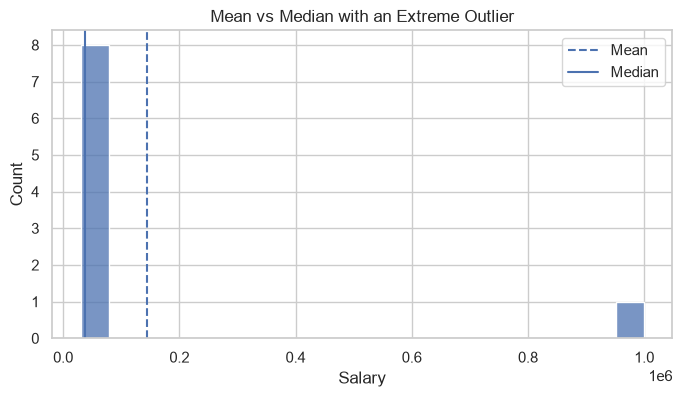

In [6]:
salaries = np.array([30000, 32000, 35000, 36000, 37000, 39000, 42000, 45000, 1000000])

print("Mean salary:", salaries.mean())
print("Median salary:", np.median(salaries))

plt.figure(figsize=(8, 4))
sns.histplot(salaries, bins=20)
plt.axvline(salaries.mean(), linestyle="--", label="Mean")
plt.axvline(np.median(salaries), linestyle="-", label="Median")
plt.title("Mean vs Median with an Extreme Outlier")
plt.xlabel("Salary")
plt.legend()
plt.show()

# 8. Measures of spread

Spread tells us how much values vary.

Main measures:

## Range
Maximum - minimum

## Variance
Average squared distance from the mean

## Standard deviation
Square root of variance

## IQR
Interquartile range = Q3 - Q1

---

Why spread matters in ML:

- Features with very large spread can dominate some models.
- Outliers can increase spread.
- High variance may indicate unstable behavior.
- Low variance features may carry little information.

In [7]:
spread_summary = pd.DataFrame({
    "min": df[numeric_cols].min(),
    "max": df[numeric_cols].max(),
    "range": df[numeric_cols].max() - df[numeric_cols].min(),
    "variance": df[numeric_cols].var(),
    "std": df[numeric_cols].std(),
    "q1": df[numeric_cols].quantile(0.25),
    "q3": df[numeric_cols].quantile(0.75),
})

spread_summary["iqr"] = spread_summary["q3"] - spread_summary["q1"]

display(spread_summary.round(2))

,min,max,range,variance,std,q1,q3,iqr
age,18.0,69.50,51.50,8.760000e+01,9.36,28.40,41.40,13.00
income,15000.0,180000.00,165000.00,5.121144e+08,22629.94,33505.25,61597.00,28091.75
website_visits,0.0,17.00,17.00,7.760000e+00,2.79,6.00,10.00,4.00
support_tickets,0.0,7.00,7.00,1.830000e+00,1.35,1.00,3.00,2.00
account_age_months,1.0,96.00,95.00,3.428400e+02,18.52,5.30,27.10,21.80
monthly_spend,5.0,91.82,86.82,2.379000e+02,15.42,19.51,40.61,21.10
satisfaction_score,18.9,100.00,81.10,2.135500e+02,14.61,64.07,83.90,19.83
discount_usage,0.7,85.10,84.40,2.607200e+02,16.15,16.18,39.12,22.95
churn,0.0,1.00,1.00,2.000000e-02,0.15,0.00,0.00,0.00


# 9. Variance and standard deviation intuition

If values are close to the mean, standard deviation is small.  
If values are far from the mean, standard deviation is large.

Let's compare two features:

- `age`
- `income`

Income has much larger spread.

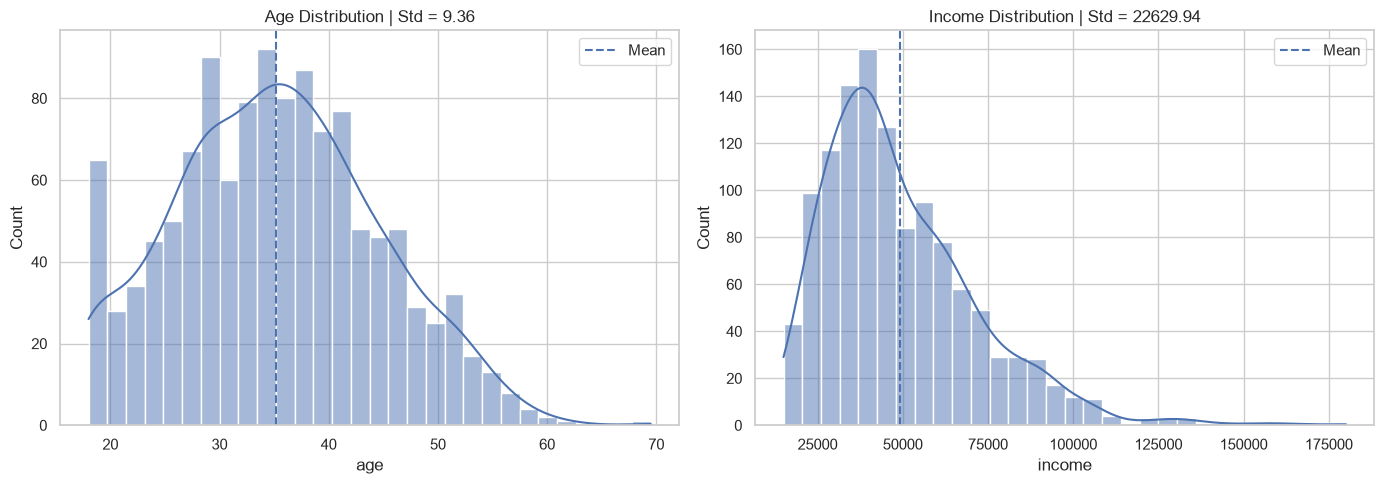

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["age"], bins=30, kde=True, ax=axes[0])
axes[0].axvline(df["age"].mean(), linestyle="--", label="Mean")
axes[0].set_title(f"Age Distribution | Std = {df['age'].std():.2f}")
axes[0].legend()

sns.histplot(df["income"], bins=30, kde=True, ax=axes[1])
axes[1].axvline(df["income"].mean(), linestyle="--", label="Mean")
axes[1].set_title(f"Income Distribution | Std = {df['income'].std():.2f}")
axes[1].legend()

plt.tight_layout()
plt.show()

# 10. Percentiles and quartiles

A percentile tells us the value below which a percentage of data falls.

Examples:

- 25th percentile = Q1
- 50th percentile = median
- 75th percentile = Q3
- 90th percentile = high value boundary

Percentiles are useful for:

- outlier detection
- business thresholds
- model monitoring
- risk scoring

In [9]:
percentile_table = pd.DataFrame({
    "p01": df[numeric_cols].quantile(0.01),
    "p05": df[numeric_cols].quantile(0.05),
    "p25": df[numeric_cols].quantile(0.25),
    "p50": df[numeric_cols].quantile(0.50),
    "p75": df[numeric_cols].quantile(0.75),
    "p95": df[numeric_cols].quantile(0.95),
    "p99": df[numeric_cols].quantile(0.99),
})

display(percentile_table.round(2))

,p01,p05,p25,p50,p75,p95,p99
age,18.00,19.19,28.40,35.00,41.40,51.21,56.50
income,16863.49,21847.90,33505.25,44103.50,61597.00,91911.50,124807.85
website_visits,2.00,4.00,6.00,8.00,10.00,13.00,15.00
support_tickets,0.00,0.00,1.00,2.00,3.00,4.00,5.01
account_age_months,1.00,1.00,5.30,13.00,27.10,57.80,87.71
monthly_spend,5.00,5.00,19.51,30.36,40.61,57.40,72.18
satisfaction_score,34.70,47.67,64.07,74.75,83.90,95.90,100.00
discount_usage,2.79,6.50,16.18,26.70,39.12,57.90,70.50
churn,0.00,0.00,0.00,0.00,0.00,0.00,1.00


# 11. Boxplot and IQR outlier rule

A boxplot is based on quartiles.

## IQR rule

```text
IQR = Q3 - Q1

Lower bound = Q1 - 1.5 × IQR
Upper bound = Q3 + 1.5 × IQR
```

Values outside these bounds are possible outliers.

Important:

Outlier does not always mean wrong data.  
It means unusual data that needs investigation.

In [10]:
def iqr_outlier_summary(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = data[(data[column] < lower) | (data[column] > upper)]

    return {
        "column": column,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": len(outliers),
        "outlier_percent": len(outliers) / len(data) * 100
    }

outlier_results = pd.DataFrame([iqr_outlier_summary(df, col) for col in numeric_cols])

display(outlier_results.round(2))

,column,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_percent
0,age,28.40,41.40,13.00,8.90,60.90,2,0.17
1,income,33505.25,61597.00,28091.75,-8632.38,103734.62,29,2.42
2,website_visits,6.00,10.00,4.00,0.00,16.00,1,0.08
3,support_tickets,1.00,3.00,2.00,-2.00,6.00,3,0.25
4,account_age_months,5.30,27.10,21.80,-27.40,59.80,52,4.33
5,monthly_spend,19.51,40.61,21.10,-12.13,72.26,11,0.92
6,satisfaction_score,64.07,83.90,19.83,34.34,113.64,11,0.92
7,discount_usage,16.18,39.12,22.95,-18.25,73.55,7,0.58
8,churn,0.00,0.00,0.00,0.00,0.00,26,2.17


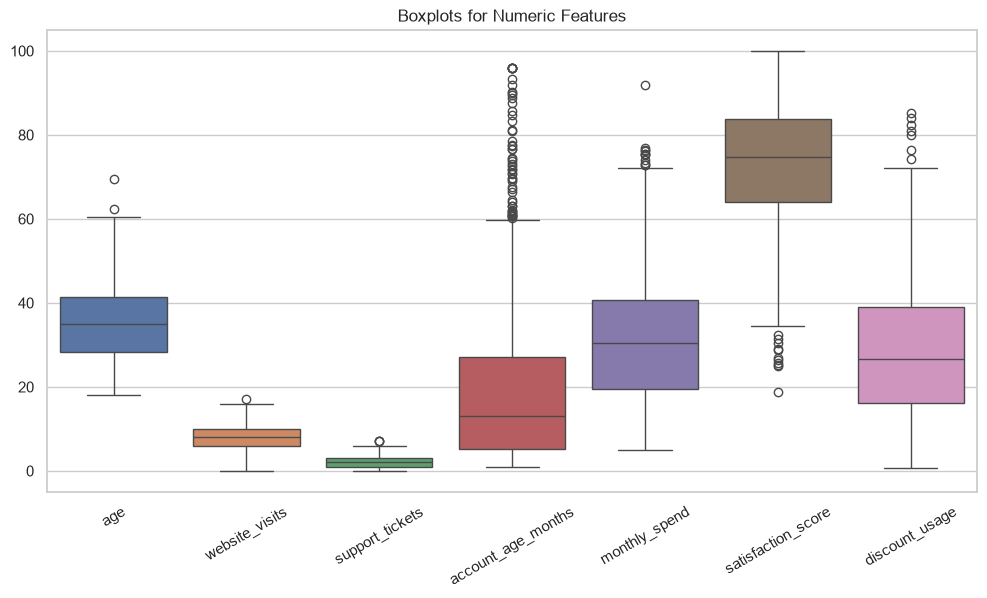

In [11]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df[["age", "website_visits", "support_tickets", "account_age_months", "monthly_spend", "satisfaction_score", "discount_usage"]])

plt.title("Boxplots for Numeric Features")
plt.xticks(rotation=30)
plt.show()

# 12. Z-score

A z-score tells how many standard deviations a value is away from the mean.

```text
z = (x - mean) / standard deviation
```

Interpretation:

- z = 0 means value is equal to the mean
- z = 1 means one standard deviation above mean
- z = -1 means one standard deviation below mean
- |z| > 3 often means possible outlier

Z-score is used in:

- standardization
- anomaly detection
- feature scaling
- comparing values from different scales

,monthly_spend,monthly_spend_z
0,5.00,-1.682760
1,16.83,-0.915767
2,5.00,-1.682760
3,21.15,-0.635682
4,36.73,0.374440


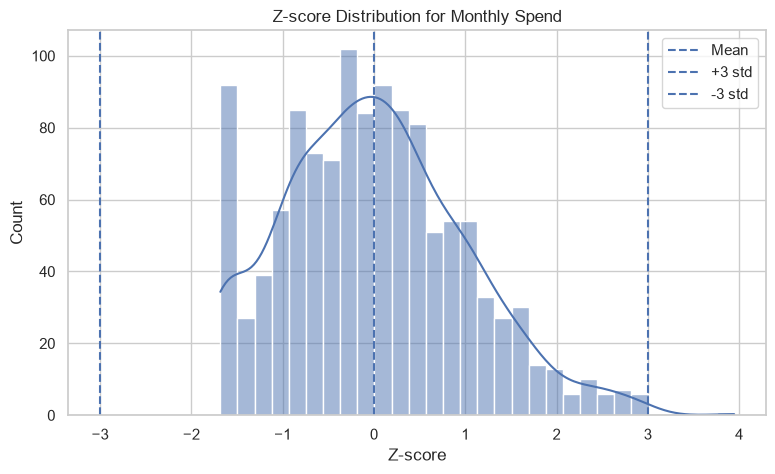

In [12]:
column = "monthly_spend"

df["monthly_spend_z"] = (df[column] - df[column].mean()) / df[column].std()

display(df[[column, "monthly_spend_z"]].head())

plt.figure(figsize=(9, 5))
sns.histplot(df["monthly_spend_z"], bins=30, kde=True)
plt.axvline(0, linestyle="--", label="Mean")
plt.axvline(3, linestyle="--", label="+3 std")
plt.axvline(-3, linestyle="--", label="-3 std")
plt.title("Z-score Distribution for Monthly Spend")
plt.xlabel("Z-score")
plt.legend()
plt.show()

# 13. Outlier detection using z-score

We can flag values where absolute z-score is greater than a threshold.

Common threshold:

```text
|z| > 3
```

But the threshold depends on the problem.

In [13]:
z_threshold = 3

z_outliers = df[np.abs(df["monthly_spend_z"]) > z_threshold]

print("Z-score outlier count:", len(z_outliers))
display(z_outliers[["monthly_spend", "monthly_spend_z"]].head())


Z-score outlier count: 1


,monthly_spend,monthly_spend_z
130,91.82,3.946174


# 14. Interactive z-score threshold

Now we use a slider to see how the threshold changes the number of detected outliers.

In [14]:
def zscore_threshold_demo(threshold=3.0):
    temp = df.copy()
    temp["is_outlier"] = np.abs(temp["monthly_spend_z"]) > threshold

    plt.figure(figsize=(10, 5))
    sns.scatterplot(
        data=temp,
        x=temp.index,
        y="monthly_spend",
        hue="is_outlier",
        alpha=0.75
    )
    plt.title(f"Monthly Spend Outliers using |z| > {threshold:.1f}")
    plt.xlabel("Customer Index")
    plt.ylabel("Monthly Spend")
    plt.show()

    print("Outlier count:", temp["is_outlier"].sum())
    print("Outlier percent:", f"{temp['is_outlier'].mean() * 100:.2f}%")

if WIDGETS_AVAILABLE:
    interact(
        zscore_threshold_demo,
        threshold=widgets.FloatSlider(value=3.0, min=1.0, max=4.5, step=0.1)
    )
else:
    zscore_threshold_demo(3.0)

interactive(children=(FloatSlider(value=3.0, description='threshold', max=4.5, min=1.0), Output()), _dom_class…

# 15. Skewness

Skewness tells whether a distribution is symmetric.

## Skewness interpretation

- close to 0: roughly symmetric
- positive skew: long tail on the right
- negative skew: long tail on the left

Income is often positively skewed.

Why skewness matters in ML:

- Highly skewed features can affect linear models.
- Transformations like log can reduce skewness.

churn                 6.579
account_age_months    1.629
income                1.324
support_tickets       0.659
discount_usage        0.608
monthly_spend         0.413
website_visits        0.267
age                   0.191
satisfaction_score   -0.495
dtype: float64

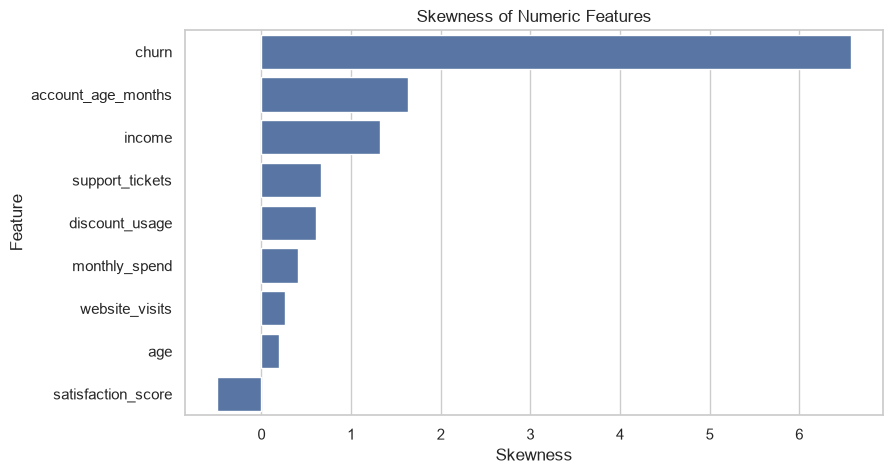

In [15]:
skew_values = df[numeric_cols].skew().sort_values(ascending=False)

display(skew_values.round(3))

plt.figure(figsize=(9, 5))
sns.barplot(x=skew_values.values, y=skew_values.index)
plt.title("Skewness of Numeric Features")
plt.xlabel("Skewness")
plt.ylabel("Feature")
plt.show()

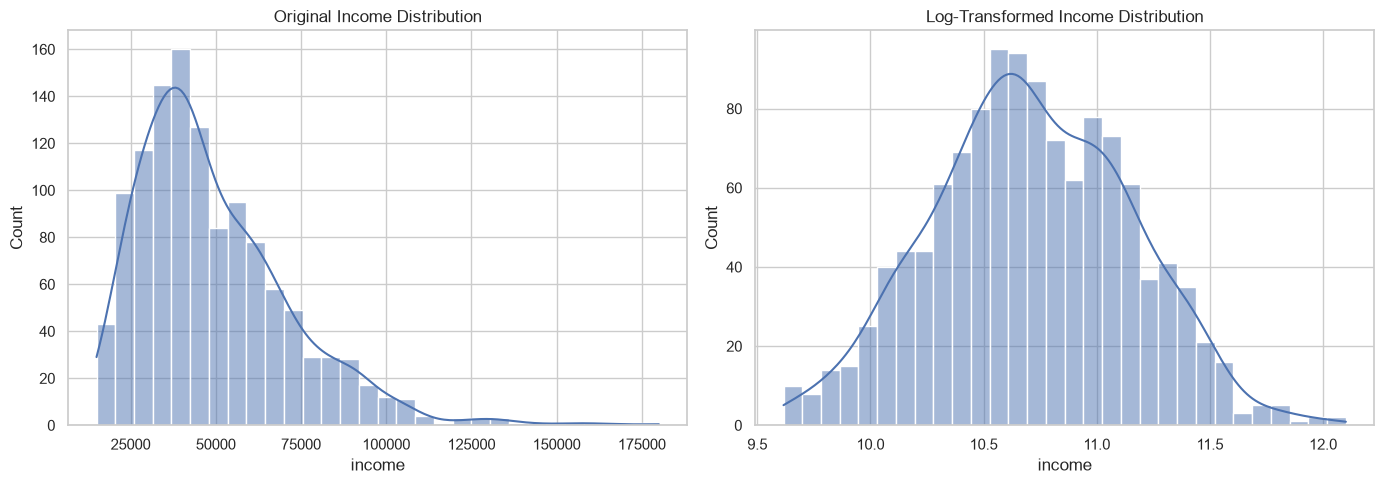

Original income skew: 1.324
Log income skew: 0.043


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["income"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Original Income Distribution")

sns.histplot(np.log1p(df["income"]), bins=30, kde=True, ax=axes[1])
axes[1].set_title("Log-Transformed Income Distribution")

plt.tight_layout()
plt.show()

print("Original income skew:", df["income"].skew().round(3))
print("Log income skew:", pd.Series(np.log1p(df["income"])).skew().round(3))

# 16. Kurtosis

Kurtosis tells how heavy the tails of a distribution are.

High kurtosis means more extreme values compared with a normal distribution.

In ML, kurtosis can help detect:

- unusual distributions
- heavy-tailed features
- risk of extreme values

churn                 41.353
account_age_months     2.854
income                 2.835
support_tickets        0.280
satisfaction_score     0.124
monthly_spend         -0.023
discount_usage        -0.087
website_visits        -0.147
age                   -0.398
dtype: float64

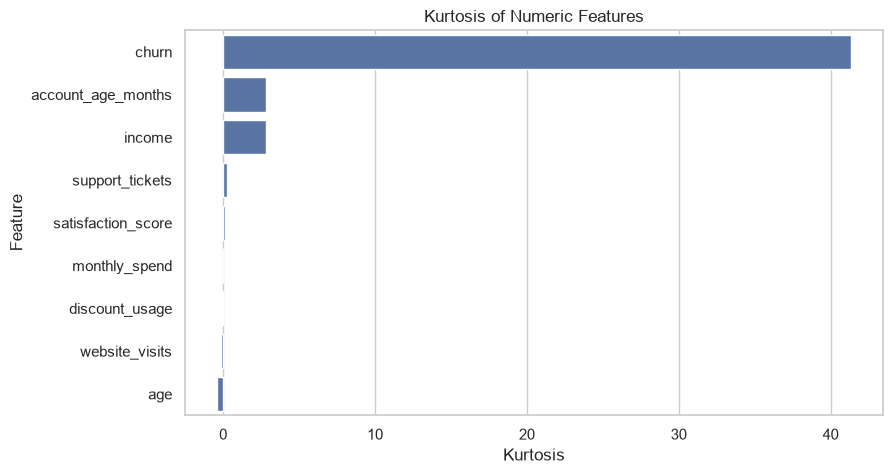

In [17]:
kurtosis_values = df[numeric_cols].kurtosis().sort_values(ascending=False)

display(kurtosis_values.round(3))

plt.figure(figsize=(9, 5))
sns.barplot(x=kurtosis_values.values, y=kurtosis_values.index)
plt.title("Kurtosis of Numeric Features")
plt.xlabel("Kurtosis")
plt.ylabel("Feature")
plt.show()

# 17. Covariance

Covariance tells whether two variables move together.

- positive covariance: variables tend to increase together
- negative covariance: one increases while the other decreases
- near zero: weak linear movement together

Problem:

Covariance depends on scale, so it is hard to compare across features.

That is why we often use correlation.

,income,monthly_spend,website_visits,support_tickets,satisfaction_score
income,5.121144e+08,214903.37,1312.17,-906.83,12528.74
monthly_spend,2.149034e+05,237.90,16.41,-6.20,65.40
website_visits,1.312170e+03,16.41,7.76,0.06,4.54
support_tickets,-9.068300e+02,-6.20,0.06,1.83,-16.71
satisfaction_score,1.252874e+04,65.40,4.54,-16.71,213.55


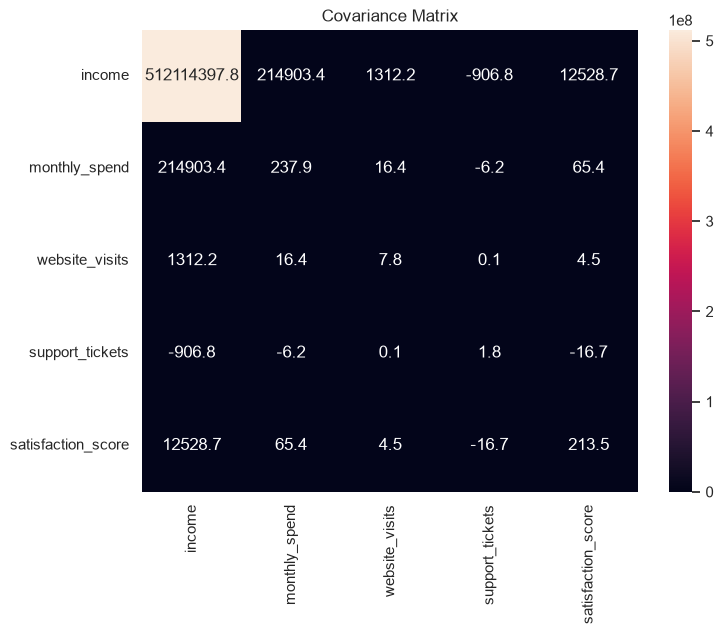

In [18]:
cov_matrix = df[["income", "monthly_spend", "website_visits", "support_tickets", "satisfaction_score"]].cov()

display(cov_matrix.round(2))

plt.figure(figsize=(8, 6))
sns.heatmap(cov_matrix, annot=True, fmt=".1f")
plt.title("Covariance Matrix")
plt.show()

# 18. Correlation

Correlation is a standardized version of covariance.

It ranges from:

- `-1`: strong negative relationship
- `0`: no linear relationship
- `+1`: strong positive relationship

Correlation helps in ML because it shows:

- feature relationships
- redundant features
- feature-target relationship
- possible multicollinearity

Important:

> Correlation does not mean causation.

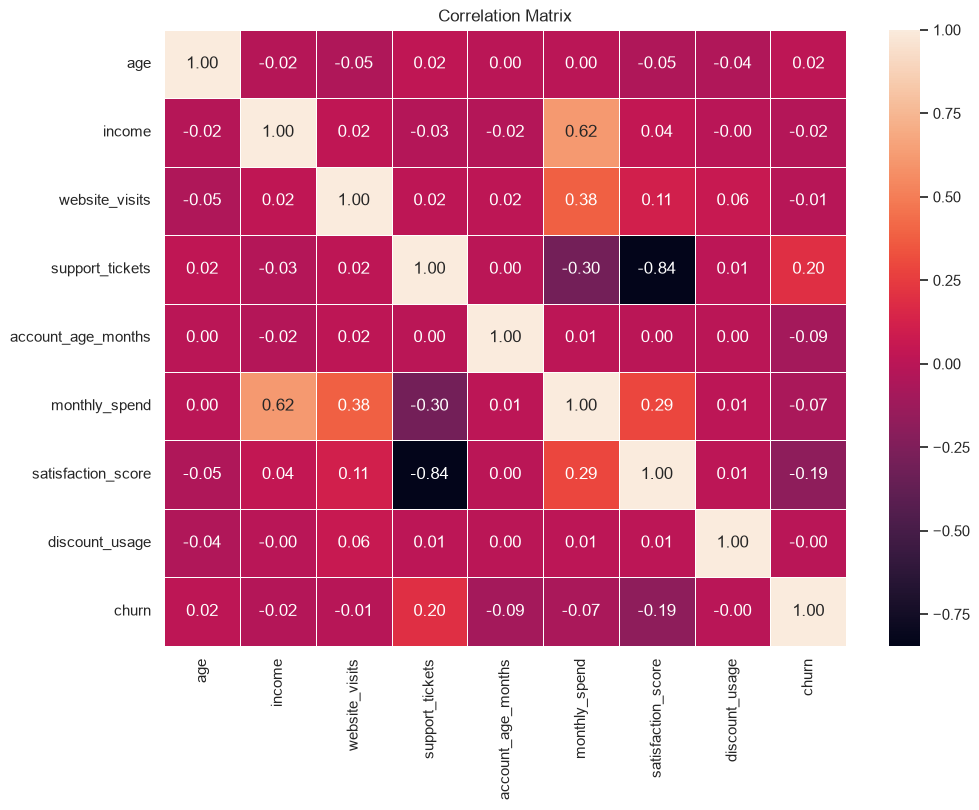

In [19]:
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Matrix")
plt.show()

# 19. Correlation with target

For ML, we often check how each feature correlates with the target.

This is not a complete feature selection method, but it gives a first idea.

support_tickets       0.196
satisfaction_score   -0.187
account_age_months   -0.092
monthly_spend        -0.069
income               -0.025
age                   0.017
website_visits       -0.009
discount_usage       -0.002
Name: churn, dtype: float64

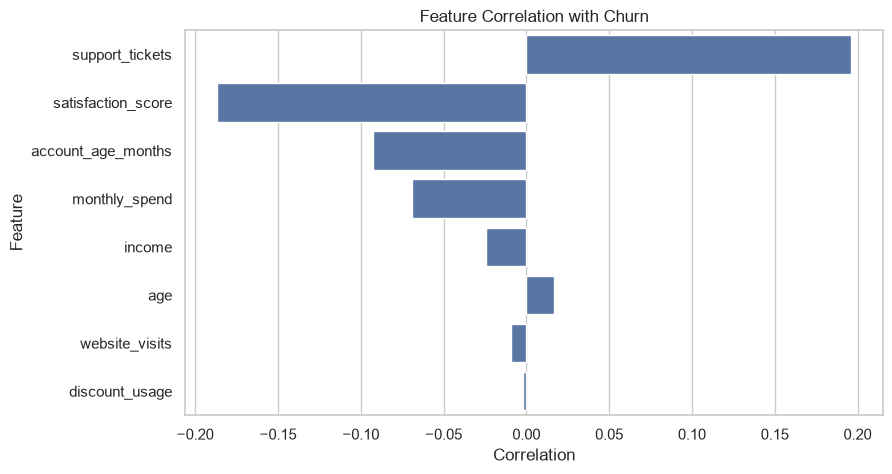

In [20]:
target_corr = corr_matrix["churn"].drop("churn").sort_values(key=lambda x: np.abs(x), ascending=False)

display(target_corr.round(3))

plt.figure(figsize=(9, 5))
sns.barplot(x=target_corr.values, y=target_corr.index)
plt.title("Feature Correlation with Churn")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.show()

# 20. Correlation can miss non-linear relationships

Correlation mostly measures linear relationship.

A variable can have a strong non-linear relationship but low correlation.

Let's create an example.

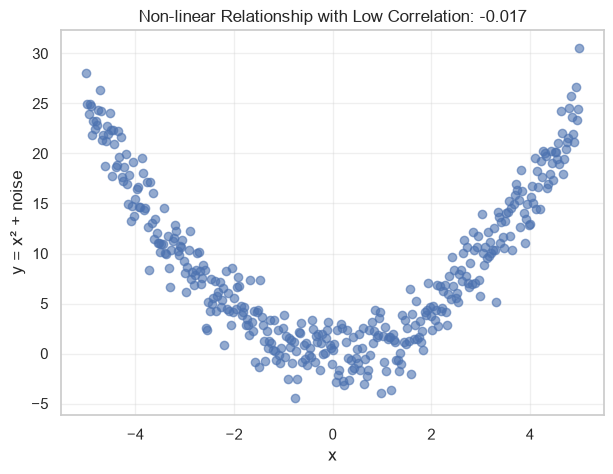

In [21]:
x = np.linspace(-5, 5, 400)
y_nonlinear = x ** 2 + np.random.normal(0, 2, size=len(x))

nonlinear_corr = np.corrcoef(x, y_nonlinear)[0, 1]

plt.figure(figsize=(7, 5))
plt.scatter(x, y_nonlinear, alpha=0.6)
plt.title(f"Non-linear Relationship with Low Correlation: {nonlinear_corr:.3f}")
plt.xlabel("x")
plt.ylabel("y = x² + noise")
plt.grid(True, alpha=0.3)
plt.show()

# 21. Feature scaling

Some ML algorithms are sensitive to feature scale.

Examples:

- Logistic Regression
- SVM
- KNN
- Neural Networks
- PCA
- Gradient descent-based models

Tree models like Random Forest are less sensitive to scaling.

## Standardization

Mean becomes 0.  
Standard deviation becomes 1.

## Min-Max Scaling

Values are scaled between 0 and 1.

In [22]:
features_to_scale = ["income", "monthly_spend", "website_visits", "support_tickets", "satisfaction_score"]

scaler = StandardScaler()
scaled_values = scaler.fit_transform(df[features_to_scale])

scaled_df = pd.DataFrame(scaled_values, columns=[col + "_standardized" for col in features_to_scale])

display(scaled_df.describe().round(2))

,income_standardized,monthly_spend_standardized,website_visits_standardized,support_tickets_standardized,satisfaction_score_standardized
count,1200.00,1200.00,1200.00,1200.00,1200.00
mean,0.00,0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00
min,-1.52,-1.68,-2.82,-1.38,-3.73
25%,-0.70,-0.74,-0.67,-0.64,-0.64
50%,-0.23,-0.04,0.05,0.10,0.09
75%,0.54,0.63,0.77,0.83,0.72
max,5.78,3.95,3.28,3.79,1.82


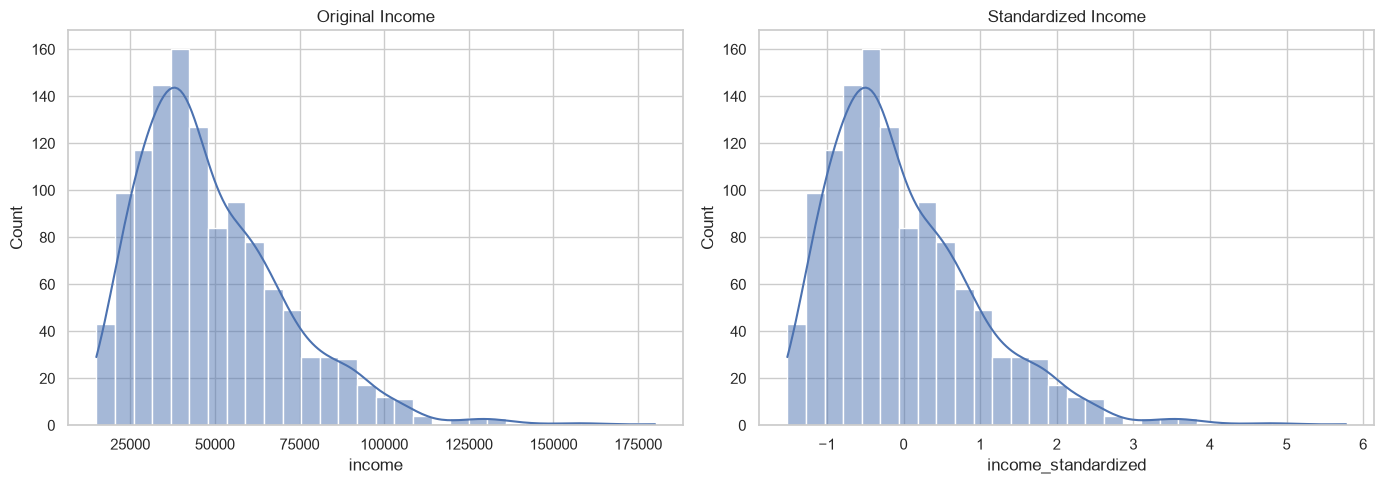

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["income"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Original Income")

sns.histplot(scaled_df["income_standardized"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Standardized Income")

plt.tight_layout()
plt.show()

# 22. Why scaling matters in ML

Let's train Logistic Regression with and without scaling.

Logistic Regression uses optimization.  
Scaling can make optimization more stable.

In [24]:
X = df[["age", "income", "website_visits", "support_tickets", "account_age_months", "monthly_spend", "satisfaction_score", "discount_usage"]]
y = df["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Model without scaling
model_no_scale = LogisticRegression(max_iter=200)
model_no_scale.fit(X_train, y_train)
pred_no_scale = model_no_scale.predict(X_test)

# Model with scaling
scale_model = StandardScaler()
X_train_scaled = scale_model.fit_transform(X_train)
X_test_scaled = scale_model.transform(X_test)

model_scaled = LogisticRegression(max_iter=200)
model_scaled.fit(X_train_scaled, y_train)
pred_scaled = model_scaled.predict(X_test_scaled)

print("Accuracy without scaling:", accuracy_score(y_test, pred_no_scale))#.round(3))
print("Accuracy with scaling:", accuracy_score(y_test, pred_scaled))#.round(3))

Accuracy without scaling: 0.98
Accuracy with scaling: 0.98


C:\Users\malik\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# 23. Low variance features

A feature with almost no variation may not help the model.

Example:

If every customer has the same country value, that feature cannot separate churn vs non-churn.

Low variance features are often removed during preprocessing.

In [25]:
df["almost_constant_feature"] = np.random.choice([1, 1, 1, 1, 2], size=len(df), p=[0.24, 0.24, 0.24, 0.24, 0.04])

variance_check = df.select_dtypes(include=np.number).var().sort_values()

display(variance_check.head(10).round(4))

churn                        0.0212
almost_constant_feature      0.0423
monthly_spend_z              1.0000
support_tickets              1.8330
website_visits               7.7596
age                         87.6028
satisfaction_score         213.5467
monthly_spend              237.8961
discount_usage             260.7214
account_age_months         342.8409
dtype: float64

# 24. Statistical profile function

In real projects, we should create reusable functions.

This function summarizes numeric columns using key statistics.

In [26]:
def statistical_profile(data):
    numeric = data.select_dtypes(include=np.number)

    profile = pd.DataFrame({
        "count": numeric.count(),
        "missing": numeric.isnull().sum(),
        "mean": numeric.mean(),
        "median": numeric.median(),
        "std": numeric.std(),
        "min": numeric.min(),
        "q1": numeric.quantile(0.25),
        "q3": numeric.quantile(0.75),
        "max": numeric.max(),
        "skew": numeric.skew(),
        "kurtosis": numeric.kurtosis()
    })

    profile["iqr"] = profile["q3"] - profile["q1"]
    profile["range"] = profile["max"] - profile["min"]

    return profile.round(3)

profile = statistical_profile(df)

display(profile)

,count,missing,mean,median,std,min,q1,q3,max,skew,kurtosis,iqr,range
age,1200,0,35.214,35.000,9.360,18.000,28.400,41.400,69.500,0.191,-0.398,13.000,51.500
income,1200,0,49314.949,44103.500,22629.945,15000.000,33505.250,61597.000,180000.000,1.324,2.835,28091.750,165000.000
website_visits,1200,0,7.861,8.000,2.786,0.000,6.000,10.000,17.000,0.267,-0.147,4.000,17.000
support_tickets,1200,0,1.870,2.000,1.354,0.000,1.000,3.000,7.000,0.659,0.280,2.000,7.000
account_age_months,1200,0,18.890,13.000,18.516,1.000,5.300,27.100,96.000,1.629,2.854,21.800,95.000
monthly_spend,1200,0,30.955,30.360,15.424,5.000,19.513,40.610,91.820,0.413,-0.023,21.097,86.820
satisfaction_score,1200,0,73.436,74.750,14.613,18.900,64.075,83.900,100.000,-0.495,0.124,19.825,81.100
discount_usage,1200,0,28.760,26.700,16.147,0.700,16.175,39.125,85.100,0.608,-0.087,22.950,84.400
churn,1200,0,0.022,0.000,0.146,0.000,0.000,0.000,1.000,6.579,41.353,0.000,1.000
monthly_spend_z,1200,0,0.000,-0.039,1.000,-1.683,-0.742,0.626,3.946,0.413,-0.023,1.368,5.629


# 25. Automated outlier summary function

This function checks IQR outliers for all numeric columns.

In [27]:
def iqr_outlier_report(data):
    numeric = data.select_dtypes(include=np.number)
    rows = []

    for col in numeric.columns:
        q1 = numeric[col].quantile(0.25)
        q3 = numeric[col].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        outlier_count = ((numeric[col] < lower) | (numeric[col] > upper)).sum()

        rows.append({
            "feature": col,
            "lower_bound": lower,
            "upper_bound": upper,
            "outlier_count": outlier_count,
            "outlier_percent": outlier_count / len(data) * 100
        })

    return pd.DataFrame(rows).sort_values("outlier_percent", ascending=False)

outlier_report = iqr_outlier_report(df)

display(outlier_report.round(2))

,feature,lower_bound,upper_bound,outlier_count,outlier_percent
10,almost_constant_feature,1.00,1.00,53,4.42
4,account_age_months,-27.40,59.80,52,4.33
1,income,-8632.38,103734.62,29,2.42
8,churn,0.00,0.00,26,2.17
6,satisfaction_score,34.34,113.64,11,0.92
9,monthly_spend_z,-2.79,2.68,11,0.92
5,monthly_spend,-12.13,72.26,11,0.92
7,discount_usage,-18.25,73.55,7,0.58
3,support_tickets,-2.00,6.00,3,0.25
0,age,8.90,60.90,2,0.17


# 26. Statistical EDA dashboard

Now we combine many statistics into one visual view.

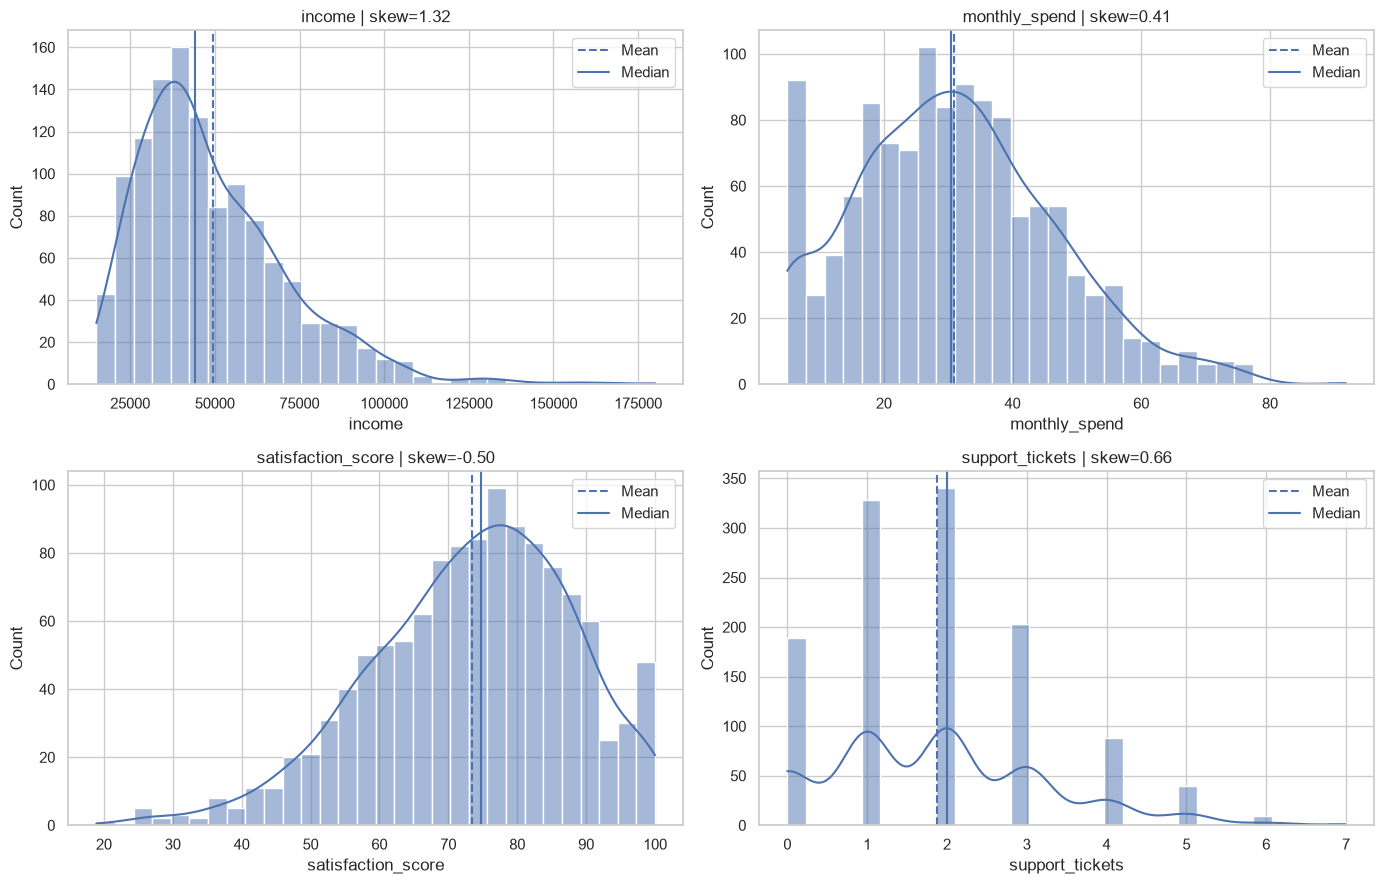

In [28]:
selected = ["income", "monthly_spend", "satisfaction_score", "support_tickets"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, col in zip(axes.ravel(), selected):
    sns.histplot(df[col], bins=30, kde=True, ax=ax)
    ax.axvline(df[col].mean(), linestyle="--", label="Mean")
    ax.axvline(df[col].median(), linestyle="-", label="Median")
    ax.set_title(f"{col} | skew={df[col].skew():.2f}")
    ax.legend()

plt.tight_layout()
plt.show()

# 27. Feature comparison by target

A useful ML question:

> Does this feature behave differently for churned and non-churned customers?

Boxplots help answer this.

C:\Users\malik\AppData\Local\Temp\ipykernel_20076\311096402.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Stayed", "Churned"])
C:\Users\malik\AppData\Local\Temp\ipykernel_20076\311096402.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Stayed", "Churned"])
C:\Users\malik\AppData\Local\Temp\ipykernel_20076\311096402.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Stayed", "Churned"])
C:\Users\malik\AppData\Local\Temp\ipykernel_20076\311096402.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using 

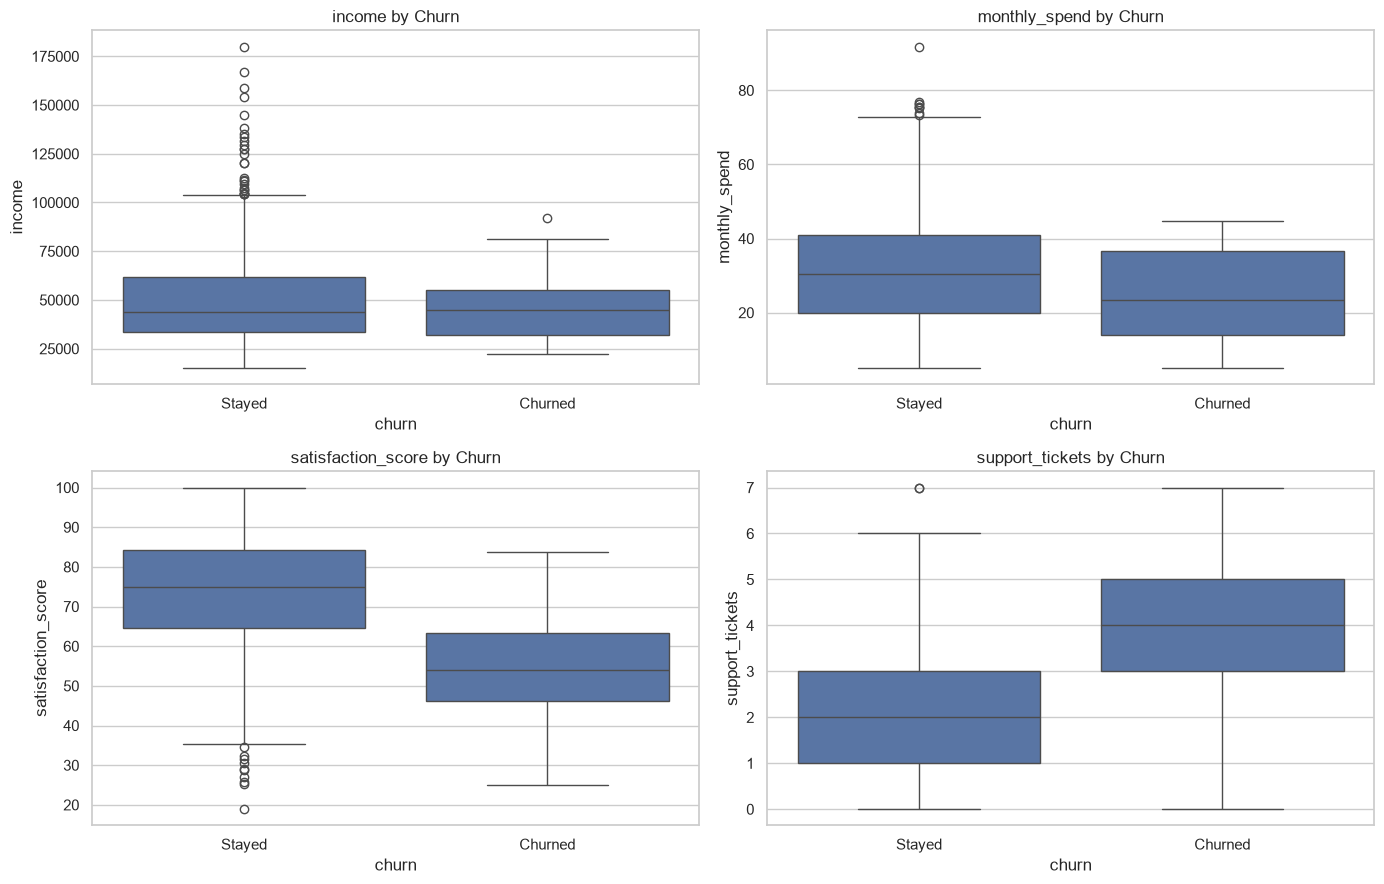

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, col in zip(axes.ravel(), selected):
    sns.boxplot(data=df, x="churn", y=col, ax=ax)
    ax.set_title(f"{col} by Churn")
    ax.set_xticklabels(["Stayed", "Churned"])

plt.tight_layout()
plt.show()

# 28. Interactive feature explorer

Now we create a small statistical feature explorer.

You can select a feature and see:

- histogram
- boxplot by target
- key statistics
- skewness
- outlier count

In [30]:
def feature_explorer(feature="monthly_spend"):
    temp = df.copy()

    stats_row = statistical_profile(temp[[feature]]).loc[feature]
    outlier_row = iqr_outlier_report(temp[[feature]]).iloc[0]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(temp[feature], bins=30, kde=True, ax=axes[0])
    axes[0].axvline(temp[feature].mean(), linestyle="--", label="Mean")
    axes[0].axvline(temp[feature].median(), linestyle="-", label="Median")
    axes[0].set_title(f"Distribution of {feature}")
    axes[0].legend()

    sns.boxplot(data=temp, x="churn", y=feature, ax=axes[1])
    axes[1].set_title(f"{feature} by Churn")
    axes[1].set_xticklabels(["Stayed", "Churned"])

    plt.tight_layout()
    plt.show()

    print("Statistical Summary")
    print("-" * 40)
    print(f"Mean: {stats_row['mean']:.3f}")
    print(f"Median: {stats_row['median']:.3f}")
    print(f"Std: {stats_row['std']:.3f}")
    print(f"Min: {stats_row['min']:.3f}")
    print(f"Max: {stats_row['max']:.3f}")
    print(f"Skew: {stats_row['skew']:.3f}")
    print(f"Kurtosis: {stats_row['kurtosis']:.3f}")
    print(f"IQR: {stats_row['iqr']:.3f}")
    print(f"Outliers: {outlier_row['outlier_count']} ({outlier_row['outlier_percent']:.2f}%)")

feature_options = [col for col in df.select_dtypes(include=np.number).columns if col != "churn"]

if WIDGETS_AVAILABLE:
    interact(
        feature_explorer,
        feature=widgets.Dropdown(options=feature_options, value="monthly_spend")
    )
else:
    feature_explorer("monthly_spend")

interactive(children=(Dropdown(description='feature', index=5, options=('age', 'income', 'website_visits', 'su…

# 29. How descriptive statistics guide ML decisions

Statistics tells us what preprocessing may be needed.

| Statistical finding | Possible ML action |
|---|---|
| Missing values | imputation |
| Outliers | investigate, cap, transform, remove |
| High skewness | log transform |
| Large scale difference | standardization |
| Low variance | remove feature |
| Strong correlation between features | check redundancy |
| Feature differs by target | useful predictive signal |
| Heavy tails | robust methods |
| Different train/test distribution | data drift check |

A strong ML engineer does not blindly train models.

They first understand the statistical behavior of the data.

# 30. Mini project — Statistical EDA Report for ML

Your task is to create a statistical report for this dataset.

## Required sections

### Section 1 — Dataset overview
- shape
- columns
- missing values
- target balance

### Section 2 — Central tendency
- mean
- median
- mode

### Section 3 — Spread
- range
- variance
- standard deviation
- IQR

### Section 4 — Distribution shape
- skewness
- kurtosis
- histograms

### Section 5 — Outliers
- IQR outlier report
- z-score outlier report
- boxplots

### Section 6 — Relationships
- covariance matrix
- correlation matrix
- target correlation

### Section 7 — ML preprocessing decisions
Write what preprocessing you would apply.

Example:
- scale income and monthly spend
- log-transform income
- investigate support ticket outliers
- remove almost constant features

### Section 8 — Insights
Write at least 8 insights.

In [31]:
# Mini project starter

print("Dataset shape:", df.shape)

print("\nTarget balance:")
display(df["churn"].value_counts(normalize=True).round(3))

print("\nStatistical profile:")
display(statistical_profile(df))

print("\nOutlier report:")
display(iqr_outlier_report(df).round(2))

print("\nCorrelation with target:")
display(df.select_dtypes(include=np.number).corr()["churn"].sort_values(ascending=False).round(3))

Dataset shape: (1200, 11)

Target balance:


churn
0    0.978
1    0.022
Name: proportion, dtype: float64


Statistical profile:


,count,missing,mean,median,std,min,q1,q3,max,skew,kurtosis,iqr,range
age,1200,0,35.214,35.000,9.360,18.000,28.400,41.400,69.500,0.191,-0.398,13.000,51.500
income,1200,0,49314.949,44103.500,22629.945,15000.000,33505.250,61597.000,180000.000,1.324,2.835,28091.750,165000.000
website_visits,1200,0,7.861,8.000,2.786,0.000,6.000,10.000,17.000,0.267,-0.147,4.000,17.000
support_tickets,1200,0,1.870,2.000,1.354,0.000,1.000,3.000,7.000,0.659,0.280,2.000,7.000
account_age_months,1200,0,18.890,13.000,18.516,1.000,5.300,27.100,96.000,1.629,2.854,21.800,95.000
monthly_spend,1200,0,30.955,30.360,15.424,5.000,19.513,40.610,91.820,0.413,-0.023,21.097,86.820
satisfaction_score,1200,0,73.436,74.750,14.613,18.900,64.075,83.900,100.000,-0.495,0.124,19.825,81.100
discount_usage,1200,0,28.760,26.700,16.147,0.700,16.175,39.125,85.100,0.608,-0.087,22.950,84.400
churn,1200,0,0.022,0.000,0.146,0.000,0.000,0.000,1.000,6.579,41.353,0.000,1.000
monthly_spend_z,1200,0,0.000,-0.039,1.000,-1.683,-0.742,0.626,3.946,0.413,-0.023,1.368,5.629



Outlier report:


,feature,lower_bound,upper_bound,outlier_count,outlier_percent
10,almost_constant_feature,1.00,1.00,53,4.42
4,account_age_months,-27.40,59.80,52,4.33
1,income,-8632.38,103734.62,29,2.42
8,churn,0.00,0.00,26,2.17
6,satisfaction_score,34.34,113.64,11,0.92
9,monthly_spend_z,-2.79,2.68,11,0.92
5,monthly_spend,-12.13,72.26,11,0.92
7,discount_usage,-18.25,73.55,7,0.58
3,support_tickets,-2.00,6.00,3,0.25
0,age,8.90,60.90,2,0.17



Correlation with target:


churn                      1.000
support_tickets            0.196
age                        0.017
discount_usage            -0.002
almost_constant_feature   -0.004
website_visits            -0.009
income                    -0.025
monthly_spend_z           -0.069
monthly_spend             -0.069
account_age_months        -0.092
satisfaction_score        -0.187
Name: churn, dtype: float64

# 31. Practice questions

Answer these in your own words.

1. What is the difference between population and sample?
2. Why is the sample important in ML?
3. What is the difference between mean and median?
4. Why is median more robust to outliers?
5. What does standard deviation tell us?
6. What is variance?
7. What is IQR?
8. How does the IQR rule detect outliers?
9. What is a z-score?
10. Why is z-score useful in ML?
11. What is skewness?
12. Why can skewness affect ML models?
13. What is kurtosis?
14. What is covariance?
15. What is correlation?
16. Why does correlation not mean causation?
17. Why can correlation miss non-linear relationships?
18. Why does feature scaling matter?
19. Which ML models are sensitive to scaling?
20. What is a low-variance feature?
21. How can statistics guide preprocessing?

# 32. What we learned

In this notebook, we learned:

- Statistics helps us understand data before ML
- Population and sample are different
- Mean, median, and mode describe center
- Range, variance, standard deviation, and IQR describe spread
- Percentiles help create thresholds
- IQR and z-score can detect outliers
- Skewness shows distribution asymmetry
- Log transform can reduce positive skewness
- Kurtosis helps identify heavy tails
- Covariance shows joint movement
- Correlation standardizes relationships
- Correlation does not mean causation
- Correlation can miss non-linear relationships
- Scaling is important for many ML algorithms
- Statistical summaries guide preprocessing
- Feature distributions by target can reveal predictive signal

---

# Next Notebook

Notebook 2 will cover:

# Probability for Machine Learning

We will learn:

- random experiments
- events
- probability rules
- conditional probability
- independence
- Bayes theorem
- probability distributions
- likelihood intuition
- ML examples like spam detection and classification uncertainty

# 📊 Statistics for Machine Learning

Statistics helps us understand data before training a machine learning model.

Before giving data to a model, we should understand:

- Where is the center of the data?
- How spread out are the values?
- Are there unusual values called outliers?
- Is the data symmetric or skewed?
- Does the data contain extreme values?
- Are two features related?
- Should features be scaled?
- Are some features almost useless because they barely change?

Statistics helps us answer these questions and make better preprocessing decisions.

---

# 1. Population vs Sample

## What is a Population?

A **population** is the complete group that we want to study.

### Example

Suppose we want to know the average height of all university students in Pakistan.

Then:

**Population = All university students in Pakistan**

The population may contain millions of students.

---

## What is a Sample?

A **sample** is a smaller group selected from the population.

For example, instead of measuring every university student in Pakistan, we select:

**1,000 students from different universities**

Then:

**Sample = Those 1,000 selected students**

We study the sample and use it to make conclusions about the complete population.

---

## Easy Example: Pot of Soup

Imagine a large pot of soup.

You do not need to drink the whole pot to check its taste.

You take one spoon.

- Complete pot = Population
- One spoon = Sample

But the soup should be mixed properly.

If you take one spoon only from the oily top layer, it may not represent the whole pot.

The same thing happens with data.

A good sample should properly represent the population.

---

# 2. Why is a Sample Important in Machine Learning?

In machine learning, collecting data from the complete population is usually impossible.

### Example

Suppose we want to build a model to predict diabetes.

The population could be:

**Every person in the world**

We cannot collect information from every person.

Instead, we collect a sample, for example:

**100,000 patients**

The model learns patterns from these patients.

After training, we expect the model to work well on new people it has never seen before.

This ability is called **generalization**.

$$
\text{Learn from Sample} \rightarrow \text{Perform well on unseen population}
$$

## Why Must the Sample be Representative?

Suppose we want to build a health model for people of all ages.

But our sample contains only people aged 18 to 25.

The model may perform well for young people but poorly for elderly people.

Therefore:

$$
\boxed{\text{Representative Sample} \rightarrow \text{Better Generalization}}
$$

A biased sample can create a biased machine learning model.

---

# 3. Mean vs Median

Both **mean** and **median** describe the center of data, but they calculate it differently.

## Mean

The mean is the arithmetic average.

$$
\text{Mean} = \frac{\text{Sum of all values}}{\text{Number of values}}
$$

Consider:

$$
2,\ 3,\ 4,\ 5,\ 6
$$

Then:

$$
\text{Mean} = \frac{2+3+4+5+6}{5}
$$

$$
\text{Mean} = 4
$$

## Median

The median is the middle value after sorting the data.

Consider:

$$
2,\ 3,\ 4,\ 5,\ 6
$$

The middle value is:

$$
\boxed{4}
$$

Therefore:

$$
\text{Median} = 4
$$

---

## What Happens When an Outlier Appears?

Consider:

$$
2,\ 3,\ 4,\ 5,\ 100
$$

Mean:

$$
\text{Mean} = \frac{2+3+4+5+100}{5}
$$

$$
\text{Mean} = 22.8
$$

Median:

$$
\text{Median} = 4
$$

The value `100` strongly changes the mean.

But the median remains close to the center of most values.

Therefore:

- Mean is sensitive to extreme values.
- Median is more robust to extreme values.

---

# 4. Why is Median More Robust to Outliers?

Consider this dataset:

$$
10,\ 11,\ 12,\ 13,\ 14
$$

The median is:

$$
12
$$

Now replace `14` with `1,000,000`:

$$
10,\ 11,\ 12,\ 13,\ 1,000,000
$$

The median is still:

$$
12
$$

Why?

Because median mainly depends on the **position of values after sorting**, not on how extremely large or small one value becomes.

The extreme value can go from:

$$
14 \rightarrow 100 \rightarrow 1000 \rightarrow 1,000,000
$$

The median still remains:

$$
12
$$

Therefore:

$$
\boxed{\text{Median is robust because extreme magnitudes have much less effect on it.}}
$$

---

# 5. What Does Standard Deviation Tell Us?

Standard deviation tells us:

> **How spread out the values are around the mean.**

Consider two datasets.

### Dataset A

$$
48,\ 49,\ 50,\ 51,\ 52
$$

### Dataset B

$$
10,\ 30,\ 50,\ 70,\ 90
$$

Both datasets have the same mean:

$$
50
$$

But Dataset A is tightly grouped around 50.

Dataset B is widely spread.

Therefore:

- Dataset A has a small standard deviation.
- Dataset B has a large standard deviation.

## Easy Interpretation

### Small Standard Deviation

Most values are close to the mean.

$$
\boxed{\text{Small SD} \rightarrow \text{Values are tightly grouped}}
$$

### Large Standard Deviation

Values are spread far from the mean.

$$
\boxed{\text{Large SD} \rightarrow \text{Values are widely spread}}
$$

---

# 6. What is Variance?

Variance also measures how spread out the data is.

It calculates the average squared distance of values from the mean.

For a population:

$$
\sigma^2 = \frac{\sum (x_i - \mu)^2}{N}
$$

Where:

- $x_i$ = each value
- $\mu$ = population mean
- $N$ = number of values

Standard deviation is the square root of variance:

$$
\sigma = \sqrt{\sigma^2}
$$

## Easy Example

Suppose two classes have the same average score.

### Class A

$$
49,\ 50,\ 51
$$

### Class B

$$
20,\ 50,\ 80
$$

Both may have the same mean, but Class B has much greater variance because its scores are much more spread out.

## Main Difference

- Variance is measured in squared units.
- Standard deviation is measured in the original units.

For example, if height is measured in centimeters:

- Variance is in $\text{cm}^2$
- Standard deviation is in $\text{cm}$

That is why standard deviation is often easier to interpret.

---

# 7. What is IQR?

IQR stands for **Interquartile Range**.

It measures the spread of the middle 50% of the data.

$$
IQR = Q_3 - Q_1
$$

Where:

- $Q_1$ = 25th percentile
- $Q_3$ = 75th percentile

Consider:

$$
1,\ 2,\ 3,\ 4,\ 5,\ 6,\ 7,\ 8,\ 9
$$

Suppose:

$$
Q_1 = 3
$$

and:

$$
Q_3 = 7
$$

Then:

$$
IQR = 7 - 3
$$

$$
IQR = 4
$$

The IQR tells us how spread out the middle half of the data is.

---




# 8. How Does the IQR Rule Detect Outliers?

The IQR method creates a lower boundary and an upper boundary.

$$
\text{Lower Bound} = Q_1 - 1.5(IQR)
$$

$$
\text{Upper Bound} = Q_3 + 1.5(IQR)
$$

Any value outside these boundaries is considered a potential outlier.

## Example

Suppose:

$$
Q_1 = 10
$$

$$
Q_3 = 20
$$

Then:

$$
IQR = 20 - 10 = 10
$$

Lower bound:

$$
10 - 1.5(10)
$$

$$
10 - 15 = -5
$$

Upper bound:

$$
20 + 1.5(10)
$$

$$
20 + 15 = 35
$$

Therefore:

- Values below `-5` are potential outliers.
- Values above `35` are potential outliers.

So:

$$
\boxed{x < -5 \text{ or } x > 35 \Rightarrow \text{Potential Outlier}}
$$

---

# 9. What is a Z-Score?

A z-score tells us:

> **How many standard deviations a value is above or below the mean.**

Formula:

$$
z = \frac{x - \mu}{\sigma}
$$

Where:

- $x$ = current value
- $\mu$ = mean
- $\sigma$ = standard deviation

## Example

Suppose:

$$
\mu = 50
$$

$$
\sigma = 10
$$

And:

$$
x = 70
$$

Then:

$$
z = \frac{70 - 50}{10}
$$

$$
z = 2
$$

This means:

> The value `70` is 2 standard deviations above the mean.

---

## How to Interpret Z-Scores

- $z = 0$ → value is exactly at the mean
- $z = 1$ → 1 standard deviation above the mean
- $z = -1$ → 1 standard deviation below the mean
- $z = 2$ → 2 standard deviations above the mean
- $z = -2$ → 2 standard deviations below the mean

A very large positive or negative z-score may indicate an unusual value.

---

# 10. Why is Z-Score Useful in Machine Learning?

Z-score is useful for:

- Feature standardization
- Comparing features with different units
- Detecting unusual values
- Helping some models train more effectively

A common standardization formula is:

$$
x' = \frac{x - \mu}{\sigma}
$$

After standardization:

$$
\text{Mean} \approx 0
$$

and:

$$
\text{Standard Deviation} \approx 1
$$

## Example

Suppose we have two features:

- Age: `18 to 60`
- Salary: `20,000 to 1,000,000`

The salary values are much larger numerically.

Standardization puts both features on a comparable scale.

---

# 11. What is Skewness?

Skewness tells us whether a distribution is symmetric or stretched more toward one side.

It measures the **asymmetry** of the distribution.

There are three main cases.

---

## 1. Symmetric Distribution

A symmetric distribution has similar shape on both sides.

Usually:

$$
\text{Mean} \approx \text{Median}
$$

Example:

$$
1,\ 2,\ 3,\ 4,\ 5
$$

The center is 3, and both sides are balanced.

Visual idea:

```text
        *
      * * *
    * * * * *
````

Skewness is approximately:

$$
0
$$

---

## 2. Right Skew or Positive Skew

In a positively skewed distribution, the long tail is on the **right side**.

Example:

$$
10,\ 11,\ 12,\ 13,\ 100
$$

Most values are small, but one very large value stretches the distribution to the right.

Visual idea:

```text
***** ***
        **
          *
            *
               *
```

Usually:

$$
\text{Mean} > \text{Median}
$$

Why?

Because the large values pull the mean toward the right.

### Real-Life Example

Income is often right-skewed.

Most people may have moderate incomes, while a small number of people have extremely high incomes.

---

## 3. Left Skew or Negative Skew

In a negatively skewed distribution, the long tail is on the **left side**.

Example:

$$
1,\ 90,\ 91,\ 92,\ 93
$$

Most values are large, but one small value stretches the distribution toward the left.

Usually:

$$
\text{Mean} < \text{Median}
$$

---

## Easy Way to Remember Skewness

Look at the direction of the **long tail**.

* Tail toward right → Positive skew
* Tail toward left → Negative skew

$$
\boxed{\text{Skewness Direction = Direction of Long Tail}}
$$

---

# 12. Why Can Skewness Affect Machine Learning Models?

Highly skewed data can cause problems because extreme values may dominate the model.

Suppose income values are:

$$
30,000,\ 35,000,\ 40,000,\ 45,000,\ 10,000,000
$$

The last value is extremely large.

This can affect:

* Distance calculations
* Gradient-based optimization
* Linear models
* Statistical assumptions
* Feature scaling

A transformation may help.

Common transformations include:

$$
\log(x)
$$

or:

$$
\sqrt{x}
$$

The goal is often to reduce extreme skewness and make the distribution easier for a model to learn from.

---

# 13. What is Kurtosis?

Kurtosis is often confusing, so let us understand it very simply.

Kurtosis tells us:

> **How likely a distribution is to produce extreme values in its tails.**

The key idea is not just the height of the peak.

The most useful interpretation is:

> **Kurtosis tells us about extreme values and the heaviness of the tails.**

---

## Easy Example

Imagine two classes.

### Class A Scores

$$
48,\ 49,\ 50,\ 51,\ 52
$$

Most values are close to the center.

There are no extreme scores.

### Class B Scores

$$
1,\ 49,\ 50,\ 51,\ 100
$$

Most values are near 50, but there are extreme values at 1 and 100.

Class B has more extreme observations in the tails.

Therefore, it has higher kurtosis.

---

## Think of Kurtosis as Extreme-Value Risk

Suppose we have two stock investments.

### Investment A

Daily returns usually stay between:

$$
-2% \text{ and } +2%
$$

### Investment B

Most days are normal, but sometimes returns suddenly become:

$$
-20% \text{ or } +25%
$$

Investment B has heavier tails and therefore higher kurtosis.

So:

$$
\boxed{\text{Higher Kurtosis} \rightarrow \text{Greater Chance of Extreme Values}}
$$

---

## Types of Kurtosis

### Mesokurtic

A normal distribution has kurtosis:

$$
3
$$

If using excess kurtosis:

$$
\text{Excess Kurtosis} = 3 - 3 = 0
$$

---

### Leptokurtic

Higher kurtosis means heavier tails and a greater chance of extreme values.

Think:

> Most values may look normal, but extreme surprises happen more often.

---

### Platykurtic

Lower kurtosis means lighter tails and fewer extreme values.

Think:

> Extreme surprises are less common.

---

## Skewness vs Kurtosis

This is very important.

### Skewness asks:

> Is the distribution stretched more toward the left or right?

### Kurtosis asks:

> How extreme are the tail observations?

Therefore:

$$
\boxed{\text{Skewness = Direction of asymmetry}}
$$

$$
\boxed{\text{Kurtosis = Tendency toward extreme tail values}}
$$

---

## Very Easy Visual Memory

Suppose five students have scores:

$$
48,\ 49,\ 50,\ 51,\ 52
$$

No extreme values.

Now:

$$
1,\ 49,\ 50,\ 51,\ 100
$$

There are extreme values on both sides.

The second dataset may still be roughly symmetric, but it has more extreme tails.

That is the idea of kurtosis.

---

# 14. What is Covariance?

Covariance tells us whether two variables tend to move together.

Formula:

$$
Cov(X,Y) = \frac{\sum (X_i-\bar{X})(Y_i-\bar{Y})}{n}
$$

The exact formula is less important than the interpretation.

---

## Positive Covariance

When one variable increases, the other also tends to increase.

Example:

* Study hours increase.
* Exam scores increase.

So:

$$
Cov(X,Y) > 0
$$

---

## Negative Covariance

When one variable increases, the other tends to decrease.

Example:

* Product price increases.
* Demand decreases.

So:

$$
Cov(X,Y) < 0
$$

---

## Covariance Near Zero

There is no clear linear tendency for the variables to move together.

The main limitation of covariance is that its value depends on the units of the variables.

That makes direct interpretation difficult.

---

# 15. What is Correlation?

Correlation measures the strength and direction of a linear relationship between two variables.

Pearson correlation is:

$$
r = \frac{Cov(X,Y)}{\sigma_X \sigma_Y}
$$

Its range is:

$$
-1 \leq r \leq 1
$$

---

## Interpretation

### Perfect Positive Correlation

$$
r = 1
$$

As one variable increases, the other increases perfectly.

---

### Perfect Negative Correlation

$$
r = -1
$$

As one variable increases, the other decreases perfectly.

---

### No Linear Correlation

$$
r \approx 0
$$

There is no clear linear relationship.

---

## Example

Suppose:

* Study hours increase.
* Exam scores also increase.

The variables may have positive correlation.

But remember:

Correlation mainly measures **linear relationships**.

---

# 16. Why Does Correlation Not Mean Causation?

Two variables may move together without one causing the other.

## Example

During summer:

* Ice cream sales increase.
* Swimming accidents may also increase.

Therefore, ice cream sales and swimming accidents may be correlated.

But:

> Eating ice cream does not cause swimming accidents.

The hidden third factor is:

**Hot weather**

Hot weather causes more people to:

* Buy ice cream
* Go swimming

This third factor is called a **confounding variable**.

Therefore:

$$
\boxed{\text{Correlation does not prove causation}}
$$

---

# 17. Why Can Correlation Miss Non-Linear Relationships?

Pearson correlation mainly detects straight-line relationships.

Consider:

$$
y = x^2
$$

Suppose:

$$
x = -2,\ -1,\ 0,\ 1,\ 2
$$

Then:

$$
y = 4,\ 1,\ 0,\ 1,\ 4
$$

Clearly, `y` completely depends on `x`.

But the relationship is curved, not straight.

The Pearson correlation may be close to zero.

Therefore:

$$
r \approx 0
$$

does not always mean:

> There is no relationship.

It may only mean:

> There is no strong linear relationship.

---

# 18. Why Does Feature Scaling Matter?

Features can have very different numerical ranges.

Example:

### Age

$$
18 \text{ to } 60
$$

### Salary

$$
20,000 \text{ to } 1,000,000
$$

Without scaling, salary has much larger numerical values.

Some machine learning models may give salary too much influence simply because its numbers are larger.

Scaling puts features on a comparable numerical scale.

---

## Standardization

Standardization transforms a feature using:

$$
x' = \frac{x-\mu}{\sigma}
$$

After standardization:

$$
\text{Mean} \approx 0
$$

$$
\text{Standard Deviation} \approx 1
$$

---

## Min-Max Scaling

Min-max scaling is:

$$
x' = \frac{x-\min(x)}{\max(x)-\min(x)}
$$

This often transforms values into:

$$
[0,1]
$$

---

# 19. Which ML Models are Sensitive to Scaling?

Some models are sensitive to feature scaling because they use distances, gradients, margins, or variance.

### Models Usually Sensitive to Scaling

* K-Nearest Neighbors
* K-Means
* Support Vector Machines
* Logistic Regression
* Neural Networks
* PCA
* Linear models with regularization

### Models Usually Less Sensitive to Scaling

* Decision Trees
* Random Forest
* Gradient-Boosted Trees

---

## Easy Rule to Remember

$$
\boxed{\text{Distance-based and gradient-based models usually need scaling}}
$$

$$
\boxed{\text{Tree-based models usually do not need scaling}}
$$

---

# 20. What is a Low-Variance Feature?

A low-variance feature has almost the same value for every observation.

Example:

$$
1,\ 1,\ 1,\ 1,\ 1
$$

This feature has zero variance.

It cannot help distinguish one observation from another.

Consider another example:

$$
1,\ 1,\ 1,\ 1,\ 1,\ 2
$$

This feature has very low variance.

It changes only once.

Such a feature may provide little useful information.

---

## Why Can Low-Variance Features Be Removed?

Suppose a dataset has a feature called:

**Country**

And every row has:

```text
Pakistan
Pakistan
Pakistan
Pakistan
Pakistan
```

This feature cannot help the model distinguish between observations.

Therefore, low-variance features may sometimes be removed during feature selection.

---

# 21. How Can Statistics Guide Preprocessing?

Statistics helps us decide what preprocessing may be needed.

| Statistical Observation                  | Possible Action                        |
| ---------------------------------------- | -------------------------------------- |
| Missing values                           | Use imputation                         |
| Strong outliers                          | Investigate, remove, cap, or transform |
| Strong skewness                          | Use log or power transformation        |
| Very different feature scales            | Apply scaling                          |
| Very low variance                        | Consider removing feature              |
| Very high correlation                    | Check for redundant features           |
| Large difference between mean and median | Investigate skewness or outliers       |
| Large standard deviation                 | Investigate high variability           |
| Heavy tails or high kurtosis             | Investigate extreme values             |

The basic workflow is:

$$
\boxed{\text{Statistics} \rightarrow \text{Understand Data} \rightarrow \text{Choose Preprocessing} \rightarrow \text{Train Better Model}}
$$

---

# Final Summary

Statistics helps us understand:

* **Population and sample** → What data are we studying?
* **Mean and median** → Where is the center?
* **Variance and standard deviation** → How spread out is the data?
* **IQR** → How spread out is the middle 50%?
* **Z-score** → How unusual is a value relative to the mean?
* **Skewness** → Is the distribution stretched to the left or right?
* **Kurtosis** → How likely are extreme values in the tails?
* **Covariance** → Do two variables move together?
* **Correlation** → How strong is their linear relationship?
* **Feature scaling** → Are features on comparable numerical scales?
* **Low variance** → Does a feature contain enough useful variation?

The most important ideas to remember are:

$$
\boxed{\text{Skewness = Direction of the long tail}}
$$

$$
\boxed{\text{Kurtosis = Tendency to produce extreme tail values}}
$$

$$
\boxed{\text{Standard Deviation = Typical spread around the mean}}
$$

$$
\boxed{\text{IQR = Spread of the middle 50% of data}}
$$

$$
\boxed{\text{Correlation measures association, not causation}}
$$

Understanding these concepts helps us clean data, transform features, detect outliers, select useful variables, and choose appropriate machine learning models.

```
```


# Why Do We Use Standard Deviation to Compare Feature Scales?

Standard deviation tells us how much the values of a numerical feature are spread around their mean.

Suppose we have:

| Feature | Standard Deviation |
|---|---:|
| Age | 8 |
| Monthly Spend | 450 |
| Income | 25,000 |

This shows that the features have very different numerical scales.

For example:

    Age varies by roughly tens.
    Monthly Spend varies by hundreds.
    Income varies by tens of thousands.

For scale-sensitive models, this difference matters because a feature with much larger numerical values may dominate calculations simply because of its units.

Examples of scale-sensitive models include:

- KNN
- K-Means
- SVM
- Logistic Regression
- Neural Networks
- PCA

A rough way to detect large scale differences is:

    std_values = numeric_df.std()
    scale_ratio = std_values.max() / std_values.min()

Suppose:

    Maximum STD = 25,000
    Minimum STD = 8

Then:

    Scale ratio = 25,000 / 8
                = 3,125

This suggests that the features have very different numerical spreads.

However, standard deviation is only a rough heuristic for deciding whether scaling is required. We should also consider:

- The model being used
- Presence of outliers
- Skewness
- Units of measurement
- Optimization method

> **Key idea:** Standard deviation gives us one number representing the spread of each feature, so it helps us roughly compare the numerical scales of different features.

---

# When Data Is Skewed, We Use the Median for the Center. What Should We Use Instead of Standard Deviation?

For approximately symmetric data, we usually use:

    Center → Mean
    Spread → Standard Deviation

For strongly skewed data or data containing extreme outliers, we usually use:

    Center → Median
    Spread → IQR

The Interquartile Range is:

$$
IQR = Q_3 - Q_1
$$

It measures the spread of the middle 50% of observations.

Suppose:

    Income = [20, 22, 25, 27, 30, 32, 500]

The extreme value `500` strongly affects:

- Mean
- Standard deviation

But it has much less influence on:

- Median
- IQR

Therefore:

| Data Shape | Center | Spread |
|---|---|---|
| Approximately symmetric | Mean | Standard Deviation |
| Strongly skewed or with outliers | Median | IQR |

We can still mathematically calculate standard deviation for skewed data:

    df["income"].std()

But it may not describe the typical spread well because extreme values strongly affect it.

> **Key idea:** Mean naturally pairs with standard deviation, while median naturally pairs with IQR.

---

# Why Does Feature Scaling Matter for Distance Calculations?

Models such as:

- KNN
- K-Means
- DBSCAN
- RBF-SVM

depend on distances between observations.

Suppose we have two customers:

    Customer A:
    Age = 30
    Income = 100,000

    Customer B:
    Age = 40
    Income = 120,000

The age difference is:

    40 - 30 = 10

The income difference is:

    120,000 - 100,000 = 20,000

Using Euclidean distance:

$$
d = \sqrt{(40-30)^2 + (120000-100000)^2}
$$

The income difference completely dominates because its numerical magnitude is much larger.

This does not necessarily mean income is more important. It may simply be measured using larger numerical units.

After scaling:

    Age difference       ≈ 0.5
    Income difference    ≈ 0.7

Now both features can contribute more fairly to the distance calculation.

> **Key idea:** Distance-based models usually need scaling because features with larger numerical magnitudes can dominate the distance calculation.

---

# Why Do Gradient-Based Models Need Feature Scaling?

Gradient-based models update their parameters using gradients.

The basic weight-update rule is:

$$
w := w - \alpha \frac{\partial L}{\partial w}
$$

where:

- $w$ is the model weight
- $\alpha$ is the learning rate
- $L$ is the loss function

Suppose:

    Age:       20 to 60
    Income:    20,000 to 500,000

Consider a linear model:

$$
\hat{y} = w_1x_1 + w_2x_2 + b
$$

where:

    x₁ = Age
    x₂ = Income

For linear regression, the gradient with respect to a weight contains the corresponding feature value:

$$
\frac{\partial L}{\partial w_j}
\propto
(\hat{y}-y)x_j
$$

Suppose the prediction error is `10`.

For age:

    Age = 30

    Gradient contribution ≈ 10 × 30
                          = 300

For income:

    Income = 100,000

    Gradient contribution ≈ 10 × 100,000
                          = 1,000,000

Therefore:

    Age gradient       = 300
    Income gradient    = 1,000,000

The gradient magnitudes are extremely different.

This can cause:

    Different feature scales
            ↓
    Very different gradient magnitudes
            ↓
    Poorly conditioned loss surface
            ↓
    Zigzagging during optimization
            ↓
    Slow convergence

After scaling:

    Age_scaled       = -0.5
    Income_scaled    = 0.7

The process becomes:

    Comparable feature scales
            ↓
    More balanced gradient magnitudes
            ↓
    Better-conditioned optimization
            ↓
    More direct movement toward the minimum
            ↓
    Faster and more stable convergence

Scaling does not mean that all features should have equal importance.

The model should still learn which features are genuinely important.

Scaling only prevents a feature from dominating because of its numerical units.

For example:

    Income in dollars = 100,000

    Same income in thousands of dollars = 100

The underlying information is identical, although the numbers are completely different.

> **Key idea:** Gradient-based models benefit from scaling because large differences in feature magnitude can create highly unbalanced gradients and make optimization slower and less stable.

---

# Why Does Scaling Matter for Linear Models?

Consider a linear model:

$$
\hat{y} = w_1x_1 + w_2x_2 + b
$$

Suppose:

    Age       ≈ 30
    Income    ≈ 100,000

Without scaling, coefficients might look like:

    Age coefficient       = 2.5
    Income coefficient    = 0.0004

This does not automatically mean age is more important.

The coefficient values are affected by the units and scales of the features.

Scaling becomes especially important when using regularization methods such as:

- Ridge
- Lasso
- Elastic Net

These methods penalize coefficient magnitude.

If features have very different scales, the regularization penalty may affect their coefficients unfairly.

> **Important:** Ordinary Linear Regression does not always require scaling for prediction accuracy, especially when solved analytically. However, scaling can improve optimization, numerical stability, coefficient comparison, and regularization behavior.

---

# Does Feature Scaling Make Data Normal?

No.

Feature scaling and distribution transformation are different operations.

For example, `StandardScaler` changes:

    Mean → approximately 0
    STD  → approximately 1

But if the original distribution is right-skewed:

    Right-skewed data
            ↓
    StandardScaler
            ↓
    Still right-skewed

StandardScaler does not fundamentally change the shape of the distribution.

Therefore:

    Scaling
    → Changes center and spread

    Log transformation
    → Can change distribution shape

    Standardization
    → Does not automatically remove skewness

> **Key idea:** Scaling changes numerical scale, while transformations such as log or Yeo-Johnson can change the shape of a distribution.

---

# What Is the Difference Between StandardScaler and RobustScaler?

## StandardScaler

StandardScaler uses:

$$
z = \frac{x-\mu}{\sigma}
$$

where:

- $\mu$ is the mean
- $\sigma$ is the standard deviation

After transformation:

    Mean ≈ 0
    STD  ≈ 1

Use StandardScaler when:

- Data is reasonably symmetric
- Extreme outliers are limited
- The model is scale-sensitive

Python:

    from sklearn.preprocessing import StandardScaler

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

## RobustScaler

RobustScaler uses:

    Center → Median
    Spread → IQR

Conceptually:

$$
x_{\text{scaled}}
=
\frac{x-\text{Median}}{IQR}
$$

It is more resistant to extreme outliers.

Python:

    from sklearn.preprocessing import RobustScaler

    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X)

The general relationship is:

    Approximately symmetric data:
    Mean + Standard Deviation
            ↓
    StandardScaler


    Strong outliers:
    Median + IQR
            ↓
    RobustScaler

However, skewness alone does not automatically mean RobustScaler is necessary.

First consider the model being used.

For example, tree-based models generally do not require feature scaling.

> **Key idea:** StandardScaler uses mean and standard deviation, whereas RobustScaler uses median and IQR, making it less sensitive to extreme outliers.

---

# What Is Log Transformation?

A log transformation changes numerical values using a logarithm.

For example:

| Original | $\log(x)$ |
|---:|---:|
| 10 | 2.30 |
| 100 | 4.61 |
| 1,000 | 6.91 |
| 10,000 | 9.21 |
| 100,000 | 11.51 |

Originally:

    10 → 100 → 1,000 → 10,000 → 100,000

The values become enormously larger.

After applying a logarithm, they become much closer together.

This happens because logarithms compress large values much more strongly than small values.

---

# Why Is Log Transformation Useful for Right-Skewed Data?

Suppose:

    Income = [20,000, 22,000, 25,000, 27,000, 30,000, 35,000, 500,000]

The extreme value `500,000` creates a long right tail.

Conceptually:

    Many smaller values
    ████████████
          ████
             ██
               █
                                  █
                                   ↑
                             Extreme value

After log transformation, the extremely large value is compressed.

This can:

- Reduce right skewness
- Reduce the influence of extremely large values
- Make some relationships more linear
- Stabilize variance in some situations
- Improve some machine learning models

In Python:

    df["income_log"] = np.log1p(df["income"])

`np.log1p(x)` calculates:

$$
\log(1+x)
$$

We often use it because:

    np.log(0)

is undefined, while:

    np.log1p(0)

returns:

    0

> **Key idea:** Log transformation compresses large values more strongly than small values, making it particularly useful for strongly right-skewed positive data.

---

# Is Log Transformation the Same as Scaling?

No.

Log transformation changes the shape of the distribution:

    np.log1p(x)

Standard scaling changes the center and spread:

$$
z = \frac{x-\mu}{\sigma}
$$

Therefore, sometimes the workflow is:

    Highly right-skewed feature
            ↓
    Log transformation
            ↓
    Less-skewed distribution
            ↓
    StandardScaler
            ↓
    Mean ≈ 0 and STD ≈ 1

> **Key idea:** Log transformation addresses distribution shape, while scaling addresses numerical magnitude.

---

# What Should We Do With Left-Skewed Data?

A left-skewed distribution has a long tail toward smaller values.

Conceptually:

    Long left tail
    ←

    ██
      ████
        ███████
           ██████████
              ████████

A traditional approach is:

    Left-skewed data
           ↓
    Reflect it
           ↓
    Becomes right-skewed
           ↓
    Apply log transformation
           ↓
    Reduce the skewness

Suppose:

    Original:

    [1, 80, 85, 90, 92, 95, 98]

A reflection can be:

    reflected = x.max() + 1 - x

The values become:

| Original | Reflected |
|---:|---:|
| 1 | 98 |
| 80 | 19 |
| 85 | 14 |
| 90 | 9 |
| 92 | 7 |
| 95 | 4 |
| 98 | 1 |

The original left tail has now become a right tail.

Then apply log:

    transformed = np.log(reflected)

The goal is not to permanently move the data from the left side to the right side.

The real goal is:

> **Reduce the long tail and make the distribution more symmetric.**

---

# After Reflecting Left-Skewed Data and Applying Log Transformation, Should We Reflect It Back?

We should separate two ideas:

1. Restoring the original direction of values
2. Restoring the original skewness

We may want to restore the original direction.

We do not want to restore the original skewness.

Suppose:

    Original small value 1
            ↓
    Reflected large value 98

and:

    Original large value 98
            ↓
    Reflected small value 1

Reflection reverses the ordering direction.

If preserving the original increasing direction is important, we can use:

    x_transformed = -np.log(x.max() + 1 - x)

The negative sign reverses the direction after the reflected log transformation.

Therefore:

    Restore original direction?  Yes, sometimes.

    Restore original skewness?   No.

The complete idea is:

    Original left-skewed data
            ↓
    Reflect
            ↓
    Right-skewed data
            ↓
    Log transformation
            ↓
    Reduce skewness
            ↓
    Optionally multiply by -1
            ↓
    Preserve original direction

> **Key idea:** We may restore the direction of the values, but we do not want to restore the original skewness that the transformation was designed to reduce.

---

# Why Do We Not Move the Data Back to the Left After Reflecting and Applying Log Transformation?

Because our real goal is not to keep the data on the left side or the right side.

Our goal is to reduce skewness.

Suppose the original data is left-skewed:

    Long tail ← Main mass

We reflect it:

    Main mass → Long tail

Now it becomes right-skewed.

Then the log transformation compresses the long right tail.

After the log transformation, the distribution may become much more symmetric.

If we perform an operation that completely restores the original left skewness, we undo the purpose of the transformation.

Therefore:

    Original left skew
            ↓
    Reflect
            ↓
    Right skew
            ↓
    Log compresses right tail
            ↓
    More symmetric distribution

If we want to preserve the original ordering direction, we can use:

    x_transformed = -np.log(x.max() + 1 - x)

This reverses the direction without restoring the original extreme skewness.

> **Key idea:** We want to restore the original direction if necessary, not restore the original skewness.

---

# Can We Apply Log Transformation to Negative Values?

Ordinary logarithms cannot directly handle negative values in real-number mathematics.

For:

$$
\log(x)
$$

the input must satisfy:

$$
x > 0
$$

For example:

    np.log(10)    # valid
    np.log(1)     # valid
    np.log(0)     # -inf
    np.log(-5)    # nan

The reason is that for every real number $y$:

$$
e^y > 0
$$

There is no real value of $y$ such that:

$$
e^y = -5
$$

Therefore:

$$
\log(-5)
$$

is not defined in the real numbers.

> **Key idea:** Ordinary logarithms require strictly positive input values.

---

# Can `np.log1p()` Handle Negative Values?

`np.log1p(x)` calculates:

$$
\log(1+x)
$$

It can handle some negative values, but only when:

$$
x > -1
$$

Examples:

    np.log1p(5)      # valid
    np.log1p(0)      # valid
    np.log1p(-0.5)   # valid
    np.log1p(-1)     # -inf
    np.log1p(-5)     # nan

Therefore, `log1p` does not solve the general problem of negative values.

---

# What Can We Do When Data Contains Negative Values?

Suppose:

    [-50, -20, -5, 0, 10, 100]

There are several approaches.

## Option 1: Shift All Values to Positive

Add a constant:

    shift = abs(x.min()) + 1
    x_positive = x + shift
    x_log = np.log(x_positive)

Example:

    Original:
    [-50, -20, -5, 0, 10, 100]

    Add 51:
    [1, 31, 46, 51, 61, 151]

    Apply log:
    [0.00, 3.43, 3.83, 3.93, 4.11, 5.02]

However, the chosen shift affects the transformation.

## Option 2: Yeo-Johnson Transformation

Yeo-Johnson can directly handle:

- Negative values
- Zero
- Positive values
- Skewness

Python:

    from sklearn.preprocessing import PowerTransformer

    transformer = PowerTransformer(method="yeo-johnson")

    x_transformed = transformer.fit_transform(
        x.reshape(-1, 1)
    )

Unlike Box-Cox, Yeo-Johnson does not require all values to be positive.

## Option 3: Signed Log Transformation

A signed log keeps negative values negative and positive values positive:

    x_transformed = np.sign(x) * np.log1p(np.abs(x))

For example:

    Original:
    -100    -10     0     10     100

    Transformed:
    -4.62   -2.40   0     2.40   4.62

A useful rule is:

| Data Values | Possible Transformation |
|---|---|
| Strictly positive | `np.log(x)` |
| Zero and positive | `np.log1p(x)` |
| Negative, zero, and positive | Yeo-Johnson |
| Preserve sign while compressing magnitude | Signed log |

---

# When Data Has a Nonlinear Relationship and Pearson Correlation Cannot Detect It, What Should We Use?

Pearson correlation mainly measures linear relationships.

Therefore, a strong nonlinear relationship can have Pearson correlation close to zero.

Consider:

$$
y = x^2
$$

Suppose:

| x | y |
|---:|---:|
| -3 | 9 |
| -2 | 4 |
| -1 | 1 |
| 0 | 0 |
| 1 | 1 |
| 2 | 4 |
| 3 | 9 |

There is a perfect mathematical relationship:

$$
y = x^2
$$

But Pearson correlation may be approximately:

    0

This happens because Pearson is looking for a straight-line relationship.

---

## Pearson Correlation

Use Pearson when the relationship is approximately linear.

    df.corr(method="pearson")

Pearson asks:

> **Do these variables move together in a straight-line pattern?**

---

## Spearman Correlation

Use Spearman for monotonic relationships.

A monotonic relationship means that as one variable increases, the other generally continues increasing or continues decreasing.

The relationship does not need to be linear.

For example:

$$
y = e^x
$$

This is nonlinear but monotonically increasing.

Use:

    df.corr(method="spearman")

Spearman asks:

> **As one variable increases, does the other generally keep increasing or decreasing?**

However, Spearman may also miss U-shaped relationships such as:

$$
y = x^2
$$

because the relationship is not monotonic across the full range.

---

## Mutual Information

For more general nonlinear relationships, use Mutual Information.

It can detect:

- Linear relationships
- Curved relationships
- U-shaped relationships
- Exponential relationships
- More complex nonlinear dependencies

For regression:

    from sklearn.feature_selection import mutual_info_regression

    mi = mutual_info_regression(X, y)

For classification:

    from sklearn.feature_selection import mutual_info_classif

    mi = mutual_info_classif(X, y)

Mutual Information asks:

> **How much information about `y` do I gain by knowing `x`?**

A useful rule is:

| Relationship Type | Useful Method |
|---|---|
| Linear | Pearson |
| Monotonic nonlinear | Spearman |
| General nonlinear dependency | Mutual Information |
| Visual inspection | Scatter Plot |

> **Key idea:** A low Pearson correlation does not necessarily mean no relationship exists. The relationship may simply be nonlinear.

---

# Why Do Tree-Based Models Become Slower When the Number of Features Increases?

Tree-based models become slower as the number of features increases because, at every node, the model searches for the best feature and split point.

Suppose the features are:

- Age
- Income
- Monthly Spend
- Tenure
- Support Tickets

At one node, the tree might test:

    Age < 30?
    Income < 50,000?
    Monthly Spend < 200?
    Tenure < 12?
    Support Tickets < 3?

For every candidate split, the tree calculates a quality measure such as:

- Gini impurity
- Entropy
- Information gain
- Variance reduction

Then it chooses the best split.

Suppose:

    Dataset A:
    10 features

    Dataset B:
    1,000 features

With 10 features, the tree searches through a relatively small number of candidates.

With 1,000 features, there are many more possible feature-threshold combinations to evaluate.

The process becomes:

    More features
        ↓
    More candidate splits
        ↓
    More impurity calculations
        ↓
    More computational work
        ↓
    Slower training

Suppose:

    Age = [20, 25, 30, 35, 40]

Possible thresholds might include:

    Age < 22.5
    Age < 27.5
    Age < 32.5
    Age < 37.5

Now imagine doing this across:

    1,000 features

The model has a much larger search space.

> **Key idea:** Tree-based models become slower with more features because every additional feature increases the number of candidate splits that may need to be evaluated.

---

# Why Can Random Forest Become Even Slower When Features Increase?

A Random Forest builds many decision trees.

Suppose:

    100 trees

Then:

    More features
          ↓
    More work per tree
          ↓
    Many trees
          ↓
    Much greater total computation

However, Random Forest often checks only a subset of features at each split.

For example:

    max_features="sqrt"

This helps:

- Reduce computational cost
- Increase diversity between trees

> **Key idea:** Random Forest can become expensive with many features because the split-search process is repeated across many trees.

---

# Why Can Irrelevant Features Be a Problem for Tree-Based Models?

Suppose only 5 features are genuinely useful, but the dataset contains 500 features.

The model may still spend time evaluating many irrelevant features.

This can cause:

- Greater computational cost
- More memory usage
- Slower training
- More opportunities for noisy splits
- Possible overfitting

The process is:

    Many irrelevant features
            ↓
    Larger search space
            ↓
    More unnecessary split evaluations
            ↓
    Slower training
            ↓
    Greater chance of noisy decisions

> **Key idea:** Irrelevant features increase computation and may also increase the risk of finding accidental noisy patterns.

---

# Why Do Tree-Based Models Usually Not Need Feature Scaling?

Tree-based models make decisions using thresholds.

For example:

    Income < 50,000?

After scaling, the equivalent decision might become:

    Income_scaled < 0.42?

The numerical values change, but the ordering of observations remains the same.

For example:

    Original:
    20,000 < 50,000 < 100,000

After scaling:

    -1.2 < 0.1 < 1.4

The order is preserved.

Therefore, the tree can still create an equivalent split.

The important difference is:

    Scaling changes feature values
            ↓
    Trees usually do not care much

    Adding more features
            ↓
    Larger split-search space
            ↓
    More computation
            ↓
    Slower training

> **Key idea:** Tree-based models are generally insensitive to feature scale because they depend on ordering and threshold comparisons rather than distances or gradient magnitudes.